# PROJET FIL ROUGE
##### Modèle de Machine Learning sur les Jeux Olympiques de 2028 à Los Angeles 

---

### **NETTOYAGE ET PRÉPARATION DES DONNÉES**

##### **Mise en place de l'environnement de base**

In [1]:
import pandas as pd # import de pandas pour manipuler, nettoyer, analyser et transformer des données tabulaires 

df = pd.read_csv("olympics_dataset.csv") # import de la source de données en dataframe

In [2]:
df.head() # observation d'un échantillon des données

,player_id,Name,Sex,Team,NOC,Year,Season,City,Sport,Event,Medal
0,0,A Dijiang,M,China,CHN,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,1,A Lamusi,M,China,CHN,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No medal
2,2,Gunnar Aaby,M,Denmark,DEN,1920,Summer,Antwerpen,Football,Football Men's Football,No medal
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,26,Cornelia (-strannood),F,Netherlands,NED,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,No medal


In [3]:
df.shape # le dataframe possède 252 565 lignes et 11 colonnes

(252565, 11)

In [4]:
df.info() # visualisation des infos générales concernant les colonnes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252565 entries, 0 to 252564
Data columns (total 11 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   player_id  252565 non-null  int64 
 1   Name       252565 non-null  object
 2   Sex        252565 non-null  object
 3   Team       252565 non-null  object
 4   NOC        252565 non-null  object
 5   Year       252565 non-null  int64 
 6   Season     252565 non-null  object
 7   City       252565 non-null  object
 8   Sport      252565 non-null  object
 9   Event      252565 non-null  object
 10  Medal      252565 non-null  object
dtypes: int64(2), object(9)
memory usage: 21.2+ MB


##### **Vérification de la qualité des données** 

In [5]:
df.isna().sum() # vérification des valeurs nulles dans le dataset - pas de valeurs nulles 

player_id    0
Name         0
Sex          0
Team         0
NOC          0
Year         0
Season       0
City         0
Sport        0
Event        0
Medal        0
dtype: int64

In [6]:
df.duplicated().sum() # vérification des doublons dans le dataset - pas de doublons

0

In [7]:
df['player_id'].nunique() # 235 903 lignes avec des id player différents, donc il y a plusieurs lignes par player, ce qui est logique. 

235903

In [8]:
df['Season'].unique() # vérification des colonnes à potentiellement supprimer - la colonne Season n'a qu'une seule valeur donc colonne vide d'info, à supprimer 

array(['Summer'], dtype=object)

In [9]:
df["NOC"].nunique() # vérification de la pertinence de la colonne par rapport à Team - 234
df["Team"].nunique() # vérification de la pertinence de la colonne par rapport à NOC - 1193

# il y a plusieurs équipes par pays, donc ces deux colonnes ne donnent pas les mêmes informations 

1193

In [10]:
df['NOC'].unique() # observation des pays uniques - on retrouve des pays obsolètes comme URS (URSS), GDR et FRG (Allemagne de l'est et de l'ouest) et EUN. 

array(['CHN', 'DEN', 'NED', 'FIN', 'NOR', 'ROU', 'EST', 'FRA', 'MAR',
       'ESP', 'EGY', 'IRI', 'BUL', 'ITA', 'CHA', 'AZE', 'SUD', 'RUS',
       'ARG', 'CUB', 'BLR', 'GRE', 'CMR', 'TUR', 'CHI', 'MEX', 'USA',
       'URS', 'NCA', 'HUN', 'NGR', 'ALG', 'KUW', 'BRN', 'PAK', 'IRQ',
       'UAR', 'LIB', 'QAT', 'MAS', 'GER', 'CAN', 'IRL', 'AUS', 'RSA',
       'ERI', 'TAN', 'JOR', 'TUN', 'LBA', 'BEL', 'DJI', 'PLE', 'COM',
       'KAZ', 'BRU', 'IND', 'KSA', 'SYR', 'MDV', 'ETH', 'UAE', 'YAR',
       'INA', 'PHI', 'SGP', 'UZB', 'KGZ', 'TJK', 'EUN', 'JPN', 'CGO',
       'SUI', 'BRA', 'GDR', 'MON', 'ISR', 'URU', 'SWE', 'SRI', 'ARM',
       'CIV', 'KEN', 'BEN', 'GBR', 'GHA', 'SOM', 'NIG', 'MLI', 'AFG',
       'POL', 'CRC', 'PAN', 'GEO', 'SLO', 'GUY', 'NZL', 'POR', 'PAR',
       'ANG', 'VEN', 'COL', 'FRG', 'BAN', 'PER', 'ESA', 'PUR', 'UGA',
       'HON', 'ECU', 'TKM', 'MRI', 'SEY', 'TCH', 'LUX', 'MTN', 'SKN',
       'TTO', 'DOM', 'VIN', 'JAM', 'LBR', 'SUR', 'NEP', 'MGL', 'AUT',
       'PLW', 'LTU',

In [11]:
df.shape

(252565, 11)

In [12]:
df_obso = df[df['NOC'].isin(['URS', 'GDR', 'FRG', 'EUN'])] # observation isolée de ces NOC obsolètes dans un dataframe

df_obso.shape # 8658 lignes, soit 3.43% de l'ensemble du dataframe - en dessous de 5% on peut supprimer les lignes osolètes.  

(9934, 11)

In [13]:
df_obso.head()

,player_id,Name,Sex,Team,NOC,Year,Season,City,Sport,Event,Medal
130,192,Rost'om Abashidze,M,Soviet Union,URS,1964,Summer,Tokyo,Wrestling,"Wrestling Men's Light-Heavyweight, Greco-Roman",No medal
131,193,Nunu (-myslaieva),F,Soviet Union,URS,1980,Summer,Moskva,Athletics,Athletics Women's Shot Put,No medal
481,550,Zagalav Abdulbekov,M,Soviet Union,URS,1972,Summer,Munich,Wrestling,"Wrestling Men's Featherweight, Freestyle",Gold
551,620,Andrey Abduvaliyev,M,Unified Team,EUN,1992,Summer,Barcelona,Athletics,Athletics Men's Hammer Throw,Gold
553,622,Dzhamolidin Abduzhaparov,M,Soviet Union,URS,1988,Summer,Seoul,Cycling,"Cycling Men's Road Race, Individual",No medal


In [14]:
df['NOC'] = df['NOC'].astype(str).str.strip().str.upper()

In [15]:
df_select = df.copy()  # copie propre du dataset original

In [16]:
# les données de pays obsolètes représentent 4.60% du dataset, donc on peut les supprimer. 

df_select = df_select[~df_select['NOC'].isin(['URS', 'GDR', 'FRG', 'EUN'])] # Garde toutes les lignes dont le NOC n’est PAS dans la liste, dans un dataframe à part sur lequel nouus travaillons
df_select = df_select[df_select["Year"] > 1960] # on ne conserve que les éditions supérieures à 1960, pour observer des jeux similaires 

##### **Valeurs aberrantes** 

In [17]:
df_select.head()

,player_id,Name,Sex,Team,NOC,Year,Season,City,Sport,Event,Medal
0,0,A Dijiang,M,China,CHN,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,1,A Lamusi,M,China,CHN,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No medal
7,31,Jyri Aalto,M,Finland,FIN,2000,Summer,Sydney,Badminton,Badminton Men's Singles,No medal
8,32,Minna Aalto,F,Finland,FIN,1996,Summer,Atlanta,Sailing,Sailing Women's Windsurfer,No medal
9,33,Minna Aalto,F,Finland,FIN,2000,Summer,Sydney,Sailing,Sailing Women's Windsurfer,No medal


Year    Axes(0.125,0.747241;0.110714x0.132759)
dtype: object

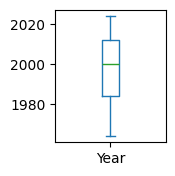

In [18]:
# Visualisation de la seule colonne numérique - pas de valeur aberrante

df_select['Year'].plot(
    kind="box",
    subplots=True,
    layout=(5, 6),
    figsize=(10, 10)
)

##### **Enrichissement avec les valeurs d'âge**

In [19]:
df_age = pd.read_csv("olympics_age.csv")

In [20]:
df_select.head()

,player_id,Name,Sex,Team,NOC,Year,Season,City,Sport,Event,Medal
0,0,A Dijiang,M,China,CHN,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,1,A Lamusi,M,China,CHN,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No medal
7,31,Jyri Aalto,M,Finland,FIN,2000,Summer,Sydney,Badminton,Badminton Men's Singles,No medal
8,32,Minna Aalto,F,Finland,FIN,1996,Summer,Atlanta,Sailing,Sailing Women's Windsurfer,No medal
9,33,Minna Aalto,F,Finland,FIN,2000,Summer,Sydney,Sailing,Sailing Women's Windsurfer,No medal


In [21]:
df_age.head()

,name,sex,age,medal,year,season,noc,country
0,Dijiang,Male,24.0,NaN,1992,summer,CHN,China
1,Lamusi,Male,23.0,NaN,2012,summer,CHN,China
2,unnar Nielsen Aaby,Male,24.0,NaN,1920,summer,DEN,Denmark
3,dgar Lindenau Aabye,Male,34.0,Gold,1900,summer,DEN,Denmark
4,hristine Jacoba Aaftink,Female,21.0,NaN,1988,winter,NED,Netherlands


In [22]:
df_age.isna().sum() # vérification des valeurs nulles dans le dataset - pas de valeurs nulles 

name            0
sex             0
age          9474
medal      256170
year            0
season          0
noc             5
country         5
dtype: int64

In [23]:
# Nettoyage
df_age = df_age.drop(columns=["country", "season", "medal"])

In [24]:
df_age["age"] = df_age["age"].round()
df_age["sex"] = df_age["sex"].replace({"Male": "M", "Female": "F"})

In [25]:
df_age.shape # 300 714 lignes et 8 colonnes dans ce dataframe 

(300714, 5)

In [26]:
df_age.isna().sum() # vérification des valeurs nulles dans le dataset 

# il y a trop de NUL dans la colonne medal donc on ne peut pas utiliser ce champ pour mercher

name       0
sex        0
age     9474
year       0
noc        5
dtype: int64

In [27]:
import unidecode

def clean_name(x):
    x = unidecode.unidecode(x)
    x = x.lower().strip()
    x = x.replace("-", " ")
    x = " ".join(x.split())
    return x

In [28]:
df_select["clean_name"] = df_select["Name"].apply(clean_name)
df_age["clean_name"] = df_age["name"].apply(clean_name)

df_select["last_name"] = df_select["clean_name"].str.split().str[-1]
df_age["last_name"] = df_age["clean_name"].str.split().str[-1]


Étape 3 — Merge souple (sans Medal)

In [29]:
df_age_unique = df_age.drop_duplicates(subset=["clean_name", "sex", "noc", "year"])

In [30]:
df_age_renamed = df_age_unique.rename(columns={
    "sex": "Sex",
    "noc": "NOC",
    "year": "Year",
    "age": "Age"
})

df_select = df_select.merge(
    df_age_renamed[["last_name", "Sex", "NOC", "Year", "Age"]],
    on=["last_name", "Sex", "NOC", "Year"],
    how="left"
)


##### **Mise en forme finale du dataframe de travail**

In [31]:
print("Taux de matching âge :", 1 - df_select["Age"].isna().mean())

# ≈ 87% de matching réussi entre df_select et df_age.

Taux de matching âge : 0.8743555542547008


In [32]:
df_select.isna().sum() # vérification des valeurs nulles dans le dataset 

# Les valeurs nulles des âges représentent 6%, on va donc remplacer les variables par la moyenne.

player_id         0
Name              0
Sex               0
Team              0
NOC               0
Year              0
Season            0
City              0
Sport             0
Event             0
Medal             0
clean_name        0
last_name         0
Age           30049
dtype: int64

In [33]:
df_select["Age"] = df_select["Age"].fillna(df_select["Age"].mean())

In [34]:
df_select.isna().sum() # vérification des valeurs nulles dans le dataset 

player_id     0
Name          0
Sex           0
Team          0
NOC           0
Year          0
Season        0
City          0
Sport         0
Event         0
Medal         0
clean_name    0
last_name     0
Age           0
dtype: int64

In [35]:
df_select.shape

(239159, 14)

##### **Encodage des données**

In [36]:
df_select['Sex'].unique()

array(['M', 'F'], dtype=object)

In [37]:
df_select["Sex_encoded"] = df_select["Sex"].map({"M": 1, "F": 0}) # encodage de Sex pour faciliter la création des champs 

In [38]:
df_select["Medal"].unique()

array(['No medal', 'Gold', 'Bronze', 'Silver'], dtype=object)

In [39]:
# Normalisation de Medal

df_select["Medal"] = df_select["Medal"].str.strip().str.lower()
df_select["Medal"] = df_select["Medal"].fillna("no medal")

In [40]:
# Encodage réaliste des médailles

df_select["Medal_encode"] = df_select["Medal"].map({
    "no medal": 0,
    "bronze": 1,
    "silver": 2,
    "gold": 3
})

In [41]:
df_select["Medal_score"] = df_select.groupby("player_id")["Medal_encode"].cumsum()

##### **Création de nouveaux champs** 

1. FEATURES ATHLÈTES

In [42]:
# Indicateur binaire : l’athlète a-t-il gagné une médaille ?
df_select["has_medal"] = (df_select["Medal_score"] > 0).astype(int)

In [43]:
# Durée de carrière olympique (première → dernière participation)

'''df["histo_athlete_years"] = (
    df.groupby("player_id")["Year"]
      .transform(lambda x: x.max() - x.min())
)'''

'df["histo_athlete_years"] = (\n    df.groupby("player_id")["Year"]\n      .transform(lambda x: x.max() - x.min())\n)'

In [44]:
# Nombre total de participations par athlète

df_select["particip_athlete"] = (
    df_select.groupby("Name")["Year"]
      .transform("count")
)

In [ ]:
# Nombre d’équipes distinctes par athlète, pays, année

df_select["nb_team"] = (
    df_select.groupby(["Name", "player_id", "NOC", "Year"])["Team"]
      .transform("nunique")
)

In [46]:
# Score médaille total par athlète

df_select["medal_score_athlete_total"] = (
    df_select.groupby("player_id")["Medal_score"]
      .transform("sum")
)

In [47]:
# Nombre total de médailles par athlète

df_select["nb_medal_athlete"] = (
    df_select.groupby("player_id")["has_medal"]
      .transform("sum")
)

In [48]:
# Nombre de médailles cumulées AVANT l'édition actuelle : cela permet d'avoir le chemin de médaille par athlète au fil des années de participation

df_select["evol_medal_athlete"] = (
    df_select.groupby("player_id")["has_medal"]
      .transform(lambda x: x.shift(1).cumsum().fillna(0))
)

2. FEATURES PAYS (NOC)

In [49]:
# Nombre total de participations par pays (années distinctes)

df_select["particip_pays"] = (
    df_select.groupby("NOC")["Year"]
      .transform("nunique")
)

In [50]:
# Nombre d’athlètes distincts par pays et année

df_select["nb_athlete_country"] = (
    df_select.groupby(["NOC", "Year"])["Name"]
      .transform("nunique")
)

In [51]:
# Nombre total de sports distincts par pays

df_select["nb_sport_country"] = (
    df_select.groupby(["NOC", "Year"])["Sport"]
      .transform("nunique")
)

In [52]:
# Score médaille total par pays

df_select["medal_score_country_total"] = (
    df_select.groupby(["NOC", "Year"])["Medal_score"]
      .transform("sum")
)

In [53]:
# Nombre total de médailles par pays

df_select["nb_medal_country"] = (
    df_select.groupby("NOC")["has_medal"]
      .transform("sum")
)

In [54]:
# Nombre de médailles cumulées : : cela permet d'avoir le chemin de médaille par athlète au fil des années de participation
# Pour chaque pays et chaque année, on calcule combien de médailles il avait AVANT cette année.

country_yearly = (
    df_select.groupby(["NOC", "Year"])[["has_medal", "Medal_score"]]
      .sum()
      .sort_values(["NOC", "Year"])
      .reset_index()
)

country_yearly["evol_medal_country"] = (
    country_yearly.groupby("NOC")["has_medal"]
    .transform(lambda x: x.shift(1).cumsum().fillna(0))
)

In [55]:
df_select = df_select.merge(
    country_yearly[["NOC", "Year", "evol_medal_country"]],
    on=["NOC", "Year"],
    how="left"
)

In [56]:
# Calcul du Ratio médaille / pays 

country_yearly = (
    df_select.groupby(["NOC", "Year"])
      .agg(
          nb_athletes=("player_id", "nunique"),
          nb_medals=("has_medal", "sum")
      )
      .reset_index()
)

In [57]:
# Taux de médaille par pays et par année

country_yearly["medal_rate"] = (
    country_yearly["nb_medals"] / country_yearly["nb_athletes"]
)

# Ce taux varie entre 0 et 1
# Il capture l’efficacité du pays

In [58]:
# Ratio : Athlètes moyens / Taux de médaille

country_yearly["athlete_medal_ratio"] = (
    country_yearly["nb_athletes"] / (country_yearly["medal_rate"] + 1e-6)
)

# Ajout de 1e-6 pour éviter une division par zéro quand un pays n’a aucune médaille une année.

In [59]:
df_select = df_select.merge(
    country_yearly[[
        "NOC", "Year",
        "nb_athletes",
        "nb_medals",
        "medal_rate",
        "athlete_medal_ratio"
    ]],
    on=["NOC", "Year"],
    how="left"
)

5. PARTIE HÔTE

In [60]:
host_countries = {
    1896: "GRE",
    1900: "FRA",
    1904: "USA",
    1908: "GBR",
    1912: "SWE",
    1920: "BEL",
    1924: "FRA",
    1928: "NED",
    1932: "USA",
    1936: "GER",
    1948: "GBR",
    1952: "FIN",
    1956: "AUS",
    1960: "ITA",
    1964: "JPN",
    1968: "MEX",
    1972: "GER",
    1976: "CAN",
    1980: "URS",
    1984: "USA",
    1988: "KOR",
    1992: "ESP",
    1996: "USA",
    2000: "AUS",
    2004: "GRE",
    2008: "CHN",
    2012: "GBR",
    2016: "BRA",
    2020: "JPN",
    2024: "FRA",
}

In [61]:
host_df = pd.DataFrame.from_dict(
    host_countries,
    orient="index",
    columns=["host_NOC"]
)
host_df.index.name = "Year"

In [62]:
df_select = df_select.merge(host_df, on="Year", how="left")

In [63]:
df_select["is_host_country"] = (df_select["NOC"] == df_select["host_NOC"]).astype(int)

In [64]:
df_select["host_NOC"] = df_select["host_NOC"].fillna("UNK")

6. FILTRE RECENT : conserver des athlètes potentiellement toujours en activité

In [65]:
from datetime import datetime

In [66]:
current_year = datetime.now().year # définir current_year

In [67]:
# Calculer l’année de première participation de chaque athlète

df_select["first_year_athlete"] = df_select.groupby("player_id")["Year"].transform("min")
df_select["years_since_first"] = current_year - df_select["first_year_athlete"]

In [68]:
# Créer un champ pour identifier les athlètes encore “récents”, qui ont un nombre d'année jusqu'à aujourd'hui inférieur à 20.

df_select["recent_athlete"] = (df_select["years_since_first"] <= 20).astype(int)

##### **Vérification des champs crées** 

In [69]:
print(df_select.shape)
print(df_select.columns)

(239159, 38)
Index(['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'Season', 'City',
       'Sport', 'Event', 'Medal', 'clean_name', 'last_name', 'Age',
       'Sex_encoded', 'Medal_encode', 'Medal_score', 'has_medal',
       'particip_athlete', 'nb_team', 'medal_score_athlete_total',
       'nb_medal_athlete', 'evol_medal_athlete', 'particip_pays',
       'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
       'nb_medal_country', 'evol_medal_country', 'nb_athletes', 'nb_medals',
       'medal_rate', 'athlete_medal_ratio', 'host_NOC', 'is_host_country',
       'first_year_athlete', 'years_since_first', 'recent_athlete'],
      dtype='object')


In [70]:
df_select.head()

,player_id,Name,Sex,Team,NOC,Year,Season,City,Sport,Event,...,evol_medal_country,nb_athletes,nb_medals,medal_rate,athlete_medal_ratio,host_NOC,is_host_country,first_year_athlete,years_since_first,recent_athlete
0,0,A Dijiang,M,China,CHN,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,...,142.0,394,131,0.332487,1185.004070,ESP,0,1992,34,0
1,1,A Lamusi,M,China,CHN,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,...,1043.0,479,166,0.346555,1382.170710,GBR,0,2012,14,1
2,31,Jyri Aalto,M,Finland,FIN,2000,Summer,Sydney,Badminton,Badminton Men's Singles,...,71.0,88,5,0.056818,1548.772742,AUS,0,2000,26,0
3,32,Minna Aalto,F,Finland,FIN,1996,Summer,Atlanta,Sailing,Sailing Women's Windsurfer,...,67.0,105,4,0.038095,2756.177650,USA,0,1996,30,0
4,33,Minna Aalto,F,Finland,FIN,2000,Summer,Sydney,Sailing,Sailing Women's Windsurfer,...,71.0,88,5,0.056818,1548.772742,AUS,0,2000,26,0


In [71]:
df_select.shape

(239159, 38)

##### **Last suppression de colonnes**

In [72]:
df_select = df_select.drop(columns=["Name", "last_name"]) # suppression des colonnes "Name" et "last_name" pour ne garder que "clean_name" et éviter les doublons

df_select = df_select.rename(columns={"clean_name": "Name"}) # on renomme ensuite "clean_name" en "Name" pour une meilleure lisibilité

In [73]:
df_select = df_select.drop(['Season'], axis=1) # suppression de la colonne Season 

##### **VIF : gestion des faetures redondantes (détecter la multicolinéarité entre les variables quantitatives)**

In [74]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

In [75]:
df_select.columns

Index(['player_id', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport', 'Event',
       'Medal', 'Name', 'Age', 'Sex_encoded', 'Medal_encode', 'Medal_score',
       'has_medal', 'particip_athlete', 'nb_team', 'medal_score_athlete_total',
       'nb_medal_athlete', 'evol_medal_athlete', 'particip_pays',
       'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
       'nb_medal_country', 'evol_medal_country', 'nb_athletes', 'nb_medals',
       'medal_rate', 'athlete_medal_ratio', 'host_NOC', 'is_host_country',
       'first_year_athlete', 'years_since_first', 'recent_athlete'],
      dtype='object')

In [76]:
df_select.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239159 entries, 0 to 239158
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   player_id                  239159 non-null  int64  
 1   Sex                        239159 non-null  object 
 2   Team                       239159 non-null  object 
 3   NOC                        239159 non-null  object 
 4   Year                       239159 non-null  int64  
 5   City                       239159 non-null  object 
 6   Sport                      239159 non-null  object 
 7   Event                      239159 non-null  object 
 8   Medal                      239159 non-null  object 
 9   Name                       239159 non-null  object 
 10  Age                        239159 non-null  float64
 11  Sex_encoded                239159 non-null  int64  
 12  Medal_encode               239159 non-null  int64  
 13  Medal_score                23

In [77]:
# Sélection des colonnes et suppression feature par feature selon les résultats du VIF - sans "has_medal" et "Medal_encode" car variables cibles 

cols_vif = [
   "Medal_score", "particip_athlete", "nb_team", "medal_score_athlete_total",
    "nb_medal_athlete", "evol_medal_athlete", "particip_pays",
    "nb_sport_country", "medal_score_country_total",
    "nb_medal_country", "evol_medal_country", "nb_athletes",
    "medal_rate", "athlete_medal_ratio", "is_host_country",
    "years_since_first", "recent_athlete", 'Sex_encoded'
]

# Colonnes supprimées : 'first_year_athlete', 'Age', 'Year', "nb_athlete_country", "nb_medals".

In [78]:
X = df_select[cols_vif]

In [79]:
# Calcul des VIF  

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [VIF(X.values, i) for i in range(X.shape[1])]
vif["Precision"] = [1 - 1/VIF(X.values, i) for i in range(X.shape[1])]

vif.sort_values("VIF", ascending=False)


,feature,VIF,Precision
2,nb_team,37.012108,0.972982
7,nb_sport_country,31.762992,0.968517
6,particip_pays,26.161747,0.961776
11,nb_athletes,24.486053,0.959160
9,nb_medal_country,15.867927,0.936980
15,years_since_first,12.339529,0.918960
0,Medal_score,8.992983,0.888802
5,evol_medal_athlete,8.689222,0.884915
4,nb_medal_athlete,6.720473,0.851201
10,evol_medal_country,6.257025,0.840180


In [80]:
df_select.columns

Index(['player_id', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport', 'Event',
       'Medal', 'Name', 'Age', 'Sex_encoded', 'Medal_encode', 'Medal_score',
       'has_medal', 'particip_athlete', 'nb_team', 'medal_score_athlete_total',
       'nb_medal_athlete', 'evol_medal_athlete', 'particip_pays',
       'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
       'nb_medal_country', 'evol_medal_country', 'nb_athletes', 'nb_medals',
       'medal_rate', 'athlete_medal_ratio', 'host_NOC', 'is_host_country',
       'first_year_athlete', 'years_since_first', 'recent_athlete'],
      dtype='object')

---

### **ANALYSE DES DONNÉES**


##### IMPORT DE L'ENVIRONNEMENT

In [81]:
import numpy as np  #calculS scientifiqueS
import seaborn as sns #visualiser avec des syntaxes simples
import matplotlib.pyplot as plt #visualiser
import sklearn as skl #Creer des modeles de machine learning (pour ce cours, on verra PCA et KMEANS)
from IPython.display import display, Markdown   #afficher
import scipy
import warnings
warnings.filterwarnings('ignore')

##### PREMIÈRES OBSERVATIONS

In [82]:
# Visualisation statistique du dataset générale

df_select.describe()

,player_id,Year,Age,Sex_encoded,Medal_encode,Medal_score,has_medal,particip_athlete,nb_team,medal_score_athlete_total,...,nb_medal_country,evol_medal_country,nb_athletes,nb_medals,medal_rate,athlete_medal_ratio,is_host_country,first_year_athlete,years_since_first,recent_athlete
count,2.391590e+05,239159.000000,239159.000000,239159.000000,239159.000000,239159.000000,239159.000000,239159.000000,239159.000000,239159.000000,...,239159.000000,239159.000000,239159.000000,239159.000000,239159.000000,2.391590e+05,239159.000000,239159.000000,239159.000000,239159.000000
mean,2.416157e+05,1997.479401,25.231098,0.631856,0.288854,0.733562,0.149156,11.837819,1.007117,7.891265,...,1285.058522,547.789341,309.590770,109.241103,0.262244,3.137595e+06,0.074076,1996.399533,29.600467,0.329868
std,4.494427e+05,17.210486,5.290533,0.482302,0.768735,3.603061,0.356243,32.004659,0.085098,64.722270,...,1655.733859,962.646881,214.762094,139.650286,0.259288,1.332749e+07,0.261895,16.885743,16.885743,0.470166
min,0.000000e+00,1964.000000,11.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,3.999992e+00,0.000000,1964.000000,2.000000,0.000000
25%,5.796250e+04,1984.000000,22.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,...,134.000000,21.000000,117.000000,10.000000,0.073826,9.085079e+02,0.000000,1984.000000,18.000000,0.000000
50%,1.350190e+05,2000.000000,25.000000,1.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,...,801.000000,196.000000,291.000000,52.000000,0.190570,1.600654e+03,0.000000,1996.000000,30.000000,0.000000
75%,2.130240e+05,2012.000000,28.000000,1.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,...,1583.000000,653.000000,461.000000,159.000000,0.344086,2.964386e+03,0.000000,2008.000000,42.000000,1.000000
max,9.460001e+06,2024.000000,71.000000,1.000000,3.000000,82.000000,1.000000,401.000000,3.000000,1216.000000,...,6374.000000,6017.000000,856.000000,577.000000,2.629630,1.370000e+08,1.000000,2024.000000,62.000000,1.000000


In [83]:
df_select.shape

(239159, 35)

In [84]:
df_select.head()

,player_id,Sex,Team,NOC,Year,City,Sport,Event,Medal,Name,...,evol_medal_country,nb_athletes,nb_medals,medal_rate,athlete_medal_ratio,host_NOC,is_host_country,first_year_athlete,years_since_first,recent_athlete
0,0,M,China,CHN,1992,Barcelona,Basketball,Basketball Men's Basketball,no medal,a dijiang,...,142.0,394,131,0.332487,1185.004070,ESP,0,1992,34,0
1,1,M,China,CHN,2012,London,Judo,Judo Men's Extra-Lightweight,no medal,a lamusi,...,1043.0,479,166,0.346555,1382.170710,GBR,0,2012,14,1
2,31,M,Finland,FIN,2000,Sydney,Badminton,Badminton Men's Singles,no medal,jyri aalto,...,71.0,88,5,0.056818,1548.772742,AUS,0,2000,26,0
3,32,F,Finland,FIN,1996,Atlanta,Sailing,Sailing Women's Windsurfer,no medal,minna aalto,...,67.0,105,4,0.038095,2756.177650,USA,0,1996,30,0
4,33,F,Finland,FIN,2000,Sydney,Sailing,Sailing Women's Windsurfer,no medal,minna aalto,...,71.0,88,5,0.056818,1548.772742,AUS,0,2000,26,0


##### DISTRIBUTION VARIABLES QUALITATIVES

In [85]:
num_cols = ["Medal_score", "particip_athlete", "nb_team", "medal_score_athlete_total",
            "nb_medal_athlete", "evol_medal_athlete", "particip_pays", 
            "nb_sport_country", "medal_score_country_total", "nb_medal_country", 
            "evol_medal_country", "nb_athletes", "medal_rate", "athlete_medal_ratio", 
            "is_host_country", "years_since_first", "recent_athlete", 
            'Sex_encoded', 'Medal_encode', "has_medal", 'is_host_country']


quali_cols = ['NOC', 'Sport', 'host_NOC', 'Sex', 'Medal']

context_cols = ['Team', 'City', 'Event', 'Name', ]

OBSERVATION : La majorité de la population d'athlètes observée dans ce dataset n'a jamais eu de médaille. 

In [86]:
# Visualisation du nombre de fois que les pays ont été hôte. 

host_counts = (
    df_select[['Year', 'host_NOC']]
    .drop_duplicates()
    .host_NOC
    .value_counts()
    .reset_index()
)

host_counts.columns = ["host_NOC", "count"]

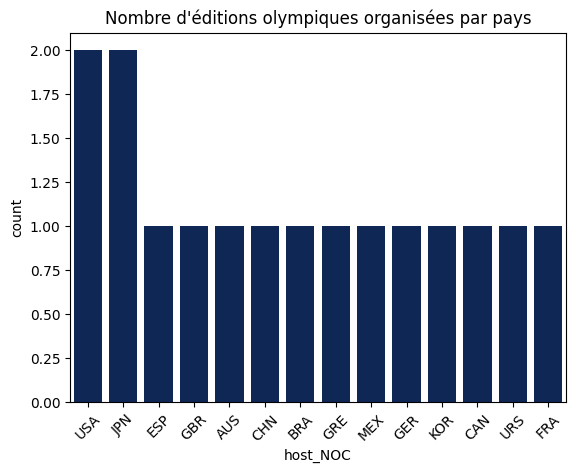

In [87]:
sns.barplot(
    data=host_counts,
    x="host_NOC",
    y="count",
    color="#032361"
)

plt.xticks(rotation=45)
plt.title("Nombre d'éditions olympiques organisées par pays")
plt.show()


OBSERVATION : La majorité des pays hôtes l'ont été 1 fois. Sauf pour les USA ont été hôtes 4 fois depuis 1960, 3 fois pour la France et le Royaume‑Uni, 2 fois pour la Grèce, l'Allemagne, le Japon et l'Australie.

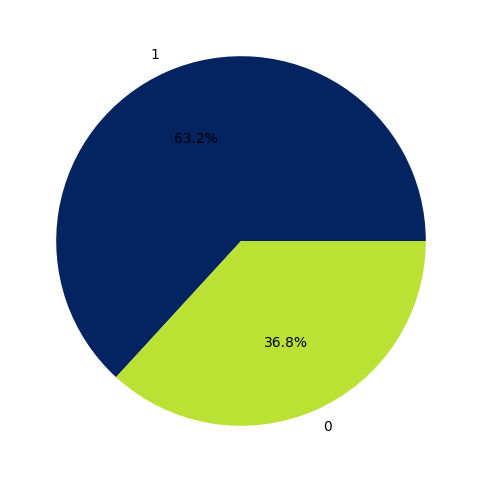

In [88]:
df_select.Sex_encoded.value_counts().plot(
    kind="pie",
    figsize=(6,6),
    autopct='%1.1f%%',
    colors=["#032361", "#bae133"]  # ordre selon value_counts()
)

plt.ylabel("")  # enlever le label 
plt.show()

OBSERVATION : La population du dataset est composée de 70% d'hommes et de 30% de femmes.

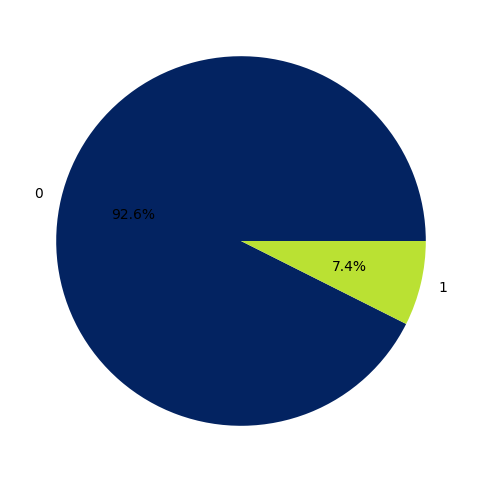

In [89]:
df_select.is_host_country.value_counts().plot(
    kind="pie",
    figsize=(6,6),
    autopct='%1.1f%%',
    colors=["#032361", "#bae133"]  # ordre selon value_counts()
)

plt.ylabel("")  # enlever le label 
plt.show()

OBSERVATION : 93% des pays n'ont jamais été hôtes. 

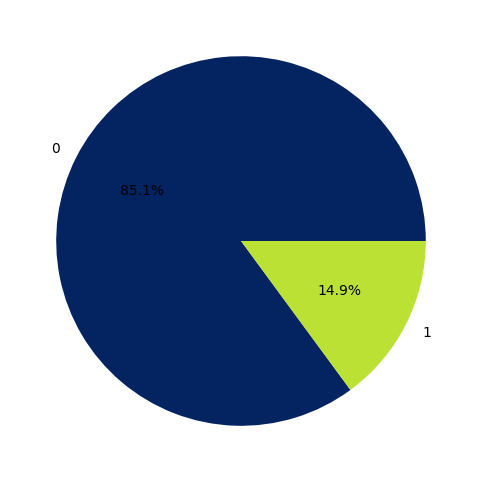

In [90]:
df_select.has_medal.value_counts().plot(
    kind="pie",
    figsize=(6,6),
    autopct='%1.1f%%',
    colors=["#032361", "#bae133"]  # ordre selon value_counts()
)

plt.ylabel("")  # enlever le label 
plt.show()

OBSERVATION : 85% des athlètes n'ont pas eu de médaille.

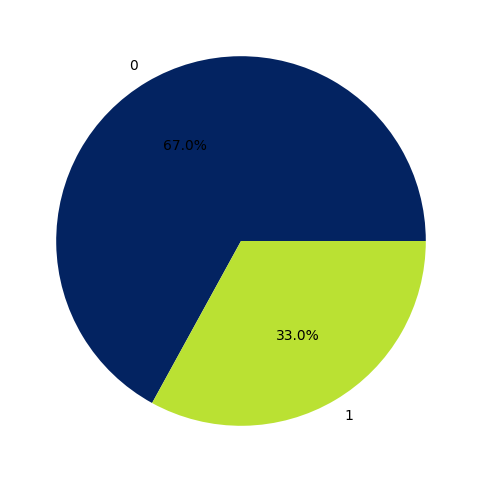

In [91]:
df_select.recent_athlete.value_counts().plot(
    kind="pie",
    figsize=(6,6),
    autopct='%1.1f%%',
    colors=["#032361", "#bae133"]  # ordre selon value_counts()
)

plt.ylabel("")  # enlever le label 
plt.show()

OBSERVATION : 33.5% des athlètes sont taggés "récents", dans le dataset.

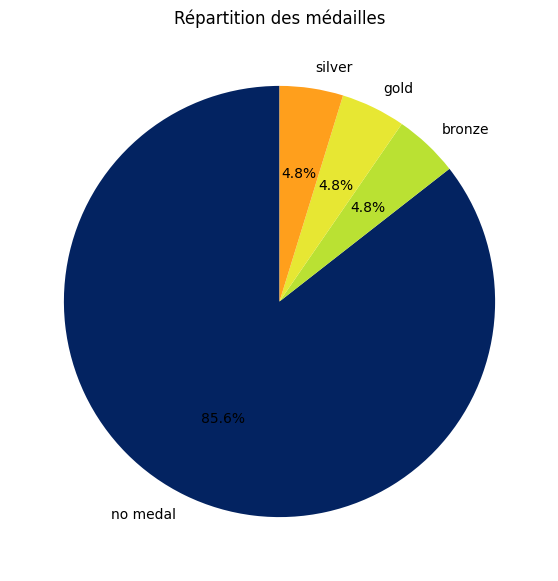

In [92]:
counts = df_select["Medal"].value_counts()

counts.plot(
    kind="pie",
    figsize=(7,7),
    autopct='%1.1f%%',
    colors=["#032361", "#bae133", "#e7e733", "#ff9f1c"],  # 4 couleurs
    startangle=90
)

plt.ylabel("")
plt.title("Répartition des médailles")
plt.show()


OBSERVATION : 85.5% des athlètes n'ont pas de médaille. La répartition des médailles silver, gold et bronze est équilibrée, entre 4.7% et 5%.

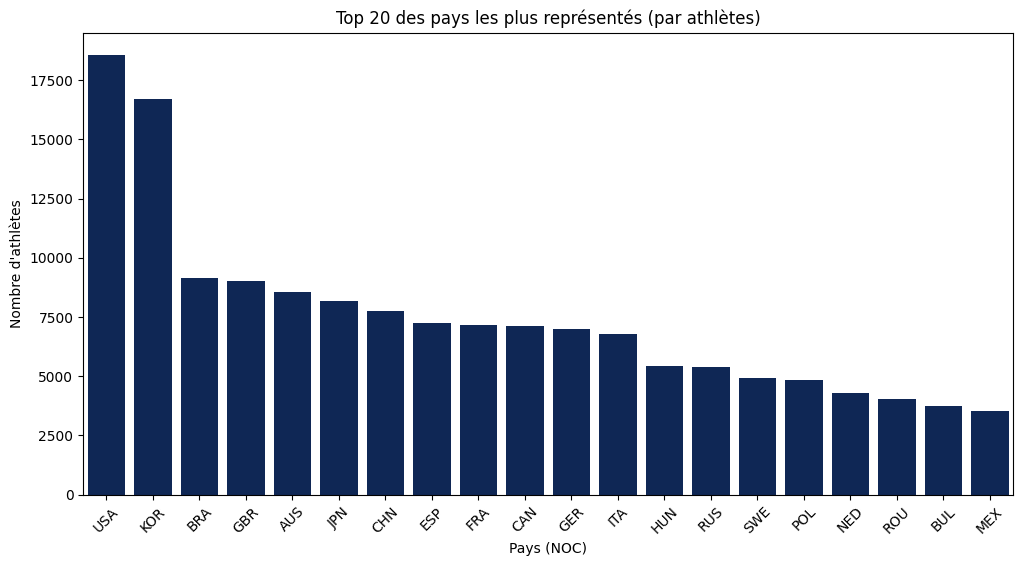

In [93]:
# Top 20 des pays les plus représentés (par athlètes)

top_100_countries = (
    df_select["NOC"]
    .value_counts()
    .head(100)
    .reset_index()
)

top_100_countries.columns = ["NOC", "nb_athletes"]

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_100_countries.head(20),
    x="NOC",
    y="nb_athletes",
    color="#032361"
)
plt.xticks(rotation=45)
plt.title("Top 20 des pays les plus représentés (par athlètes)")
plt.xlabel("Pays (NOC)")
plt.ylabel("Nombre d'athlètes")
plt.show()


OBSERVATION : les pays les plus représentés sont les USA, le Royaume-Uni et la France.

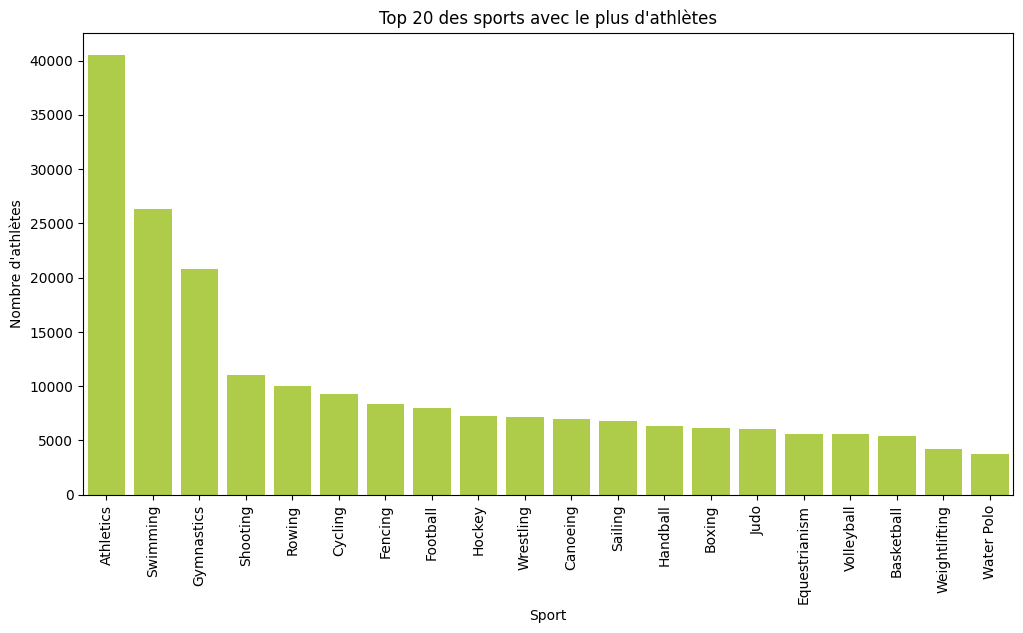

In [94]:
# Top 20 sports les plus représentés

top_100_sports = (
    df_select["Sport"]
    .value_counts()
    .head(100)
    .reset_index()
)

top_100_sports.columns = ["Sport", "nb_athletes"]

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_100_sports.head(20),
    x="Sport",
    y="nb_athletes",
    color="#bae133"
)
plt.xticks(rotation=90)
plt.title("Top 20 des sports avec le plus d'athlètes")
plt.xlabel("Sport")
plt.ylabel("Nombre d'athlètes")
plt.show()


OBSERVATION : les sports les plus représentés aux JO sont l'Athlétisme, la gymnastique et la natation.

##### DISTRIBUTION VARIABLES NUMÉRIQUES 

Medal_score
0     203487
2       9289
1       8687
3       8542
6       1976
4       1551
9        669
12       640
8        498
18       364
5        343
10       340
15       297
24       221
14       193
21       186
7        172
16       164
30       144
27       138
20       108
33        92
36        91
22        84
42        75
48        63
39        62
11        60
45        57
26        52
28        50
51        45
13        39
54        38
32        31
34        30
63        24
60        24
57        24
17        18
66        18
69        18
38        15
72        14
78        14
40        14
75        14
46        13
44        13
19        13
50        12
52        12
81        10
23         5
25         4
55         1
82         1
Name: count, dtype: int64


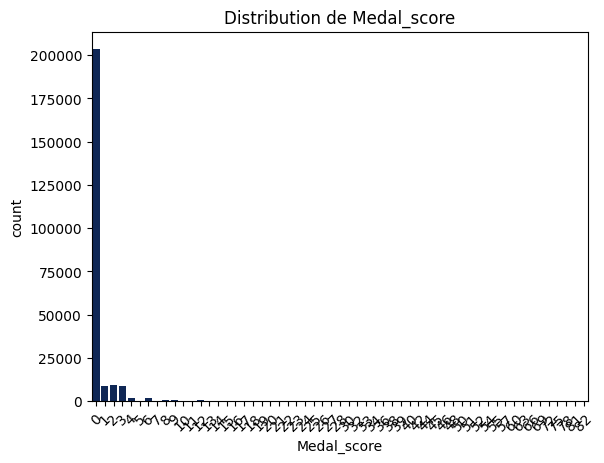

Year
1996    20209
2000    18748
2008    18556
2016    18375
2004    18048
1992    17654
2012    17440
1988    16885
2020    15942
2024    15689
1984    11909
1972    11614
1964    10218
1968     9801
1976     9699
1980     8372
Name: count, dtype: int64


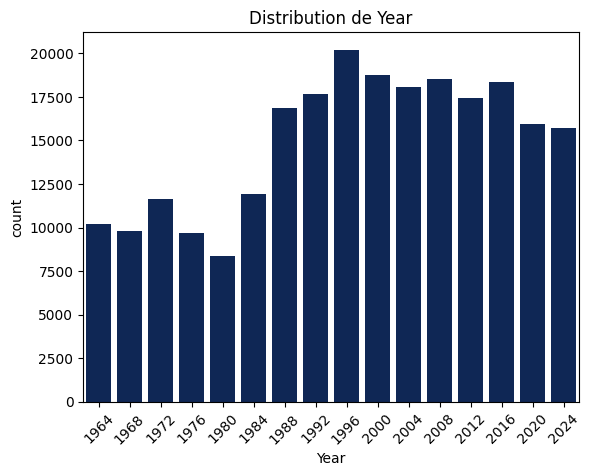

nb_team
1    237478
2      1660
3        21
Name: count, dtype: int64


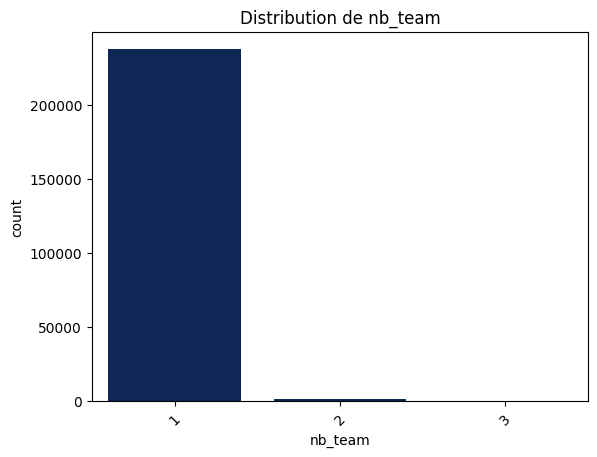

medal_score_athlete_total
0     201275
3       7911
2       7600
1       7576
6       2202
       ...  
61         7
32         6
38         5
33         5
19         4
Name: count, Length: 104, dtype: int64


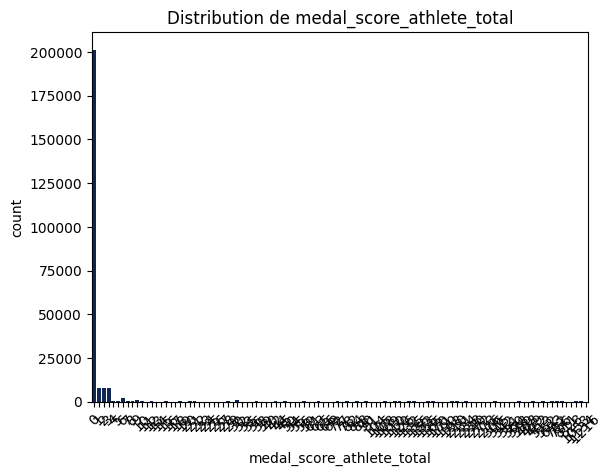

nb_medal_athlete
0     201275
1      21292
2       5456
3       2039
4       1425
5        949
6        727
8        687
9        595
17       561
7        515
27       513
10       512
12       510
11       441
15       330
14       252
26       234
21       210
18       180
16       160
23       138
19        76
28        56
13        26
Name: count, dtype: int64


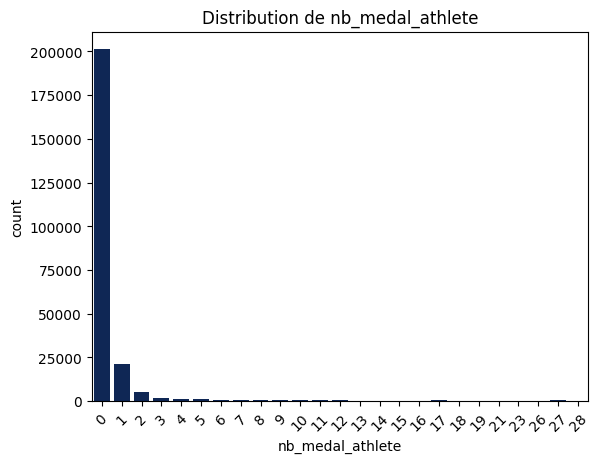

years_since_first
30    21057
26    19588
18    19368
10    19331
22    18867
34    18395
14    18290
38    17585
2     15689
42    12539
54    12275
62    10643
58    10339
50    10185
46     8795
6      6213
Name: count, dtype: int64


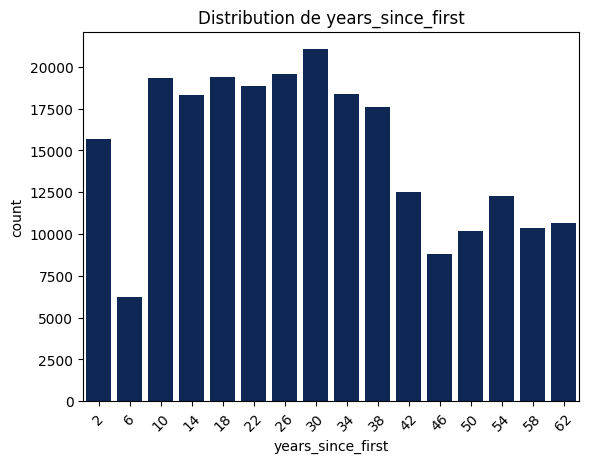

In [95]:
num_cols = df_select[["Medal_score", "Year", "nb_team", "medal_score_athlete_total",
            "nb_medal_athlete", "years_since_first"]]


for col in num_cols:
    print(df_select[col].value_counts())
    sns.countplot(data=df_select, x=col, color="#032361")
    plt.xticks(rotation=45)
    plt.title(f"Distribution de {col}")
    plt.show()

OBSERVATION : 
- Fin 1990 : explostion de la participation d'athlètes (pic 2020). 
- La majorité des athlètes ont participé entre 1 à 4 fois sur toute la période observée. 
- 1 équipe par athlète par année. 
- La majorité des athlètes ont un historique de 2 à 38 ans. 

In [96]:
df_select.shape

(239159, 35)

In [97]:
df_select.columns

Index(['player_id', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport', 'Event',
       'Medal', 'Name', 'Age', 'Sex_encoded', 'Medal_encode', 'Medal_score',
       'has_medal', 'particip_athlete', 'nb_team', 'medal_score_athlete_total',
       'nb_medal_athlete', 'evol_medal_athlete', 'particip_pays',
       'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
       'nb_medal_country', 'evol_medal_country', 'nb_athletes', 'nb_medals',
       'medal_rate', 'athlete_medal_ratio', 'host_NOC', 'is_host_country',
       'first_year_athlete', 'years_since_first', 'recent_athlete'],
      dtype='object')

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

In [99]:
num_cols = ['particip_pays', 'nb_sport_country', 'medal_score_country_total', 
            'nb_athletes', 'medal_rate', 'Age', 'particip_athlete', "evol_medal_athlete", 
            "nb_medal_country", "evol_medal_country", "athlete_medal_ratio"]

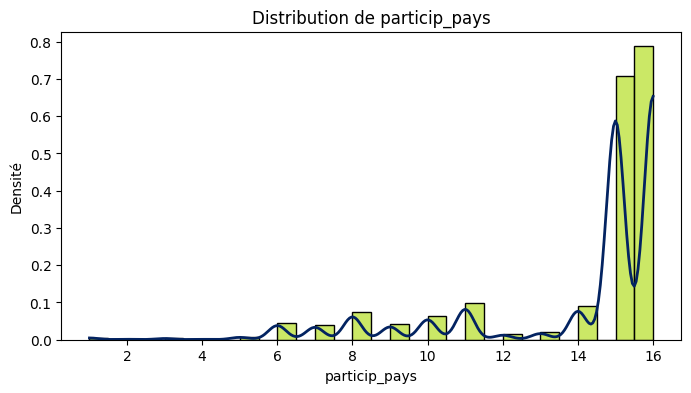

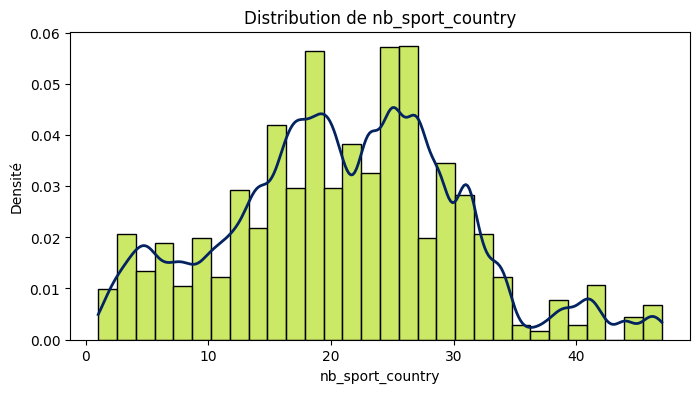

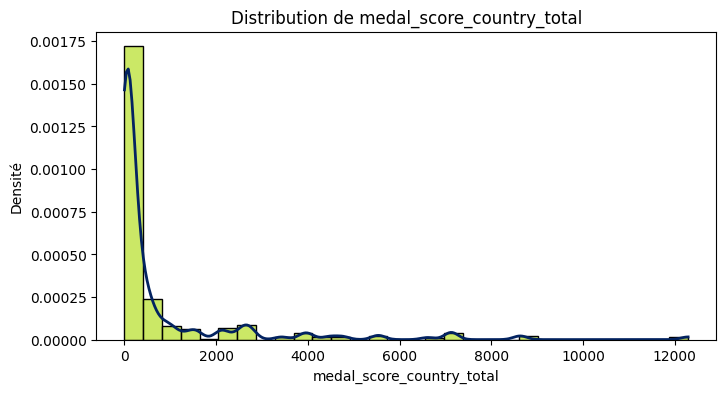

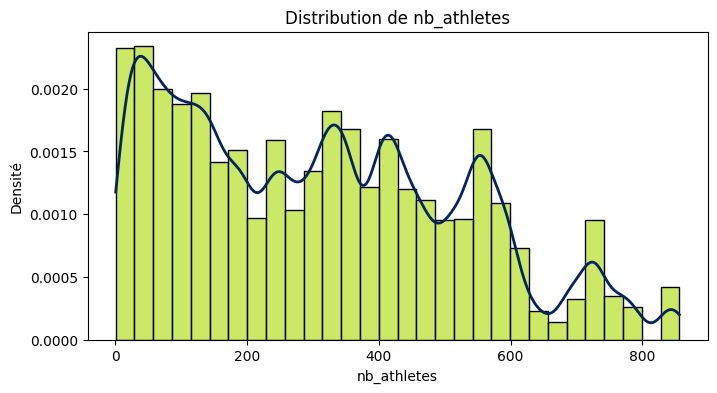

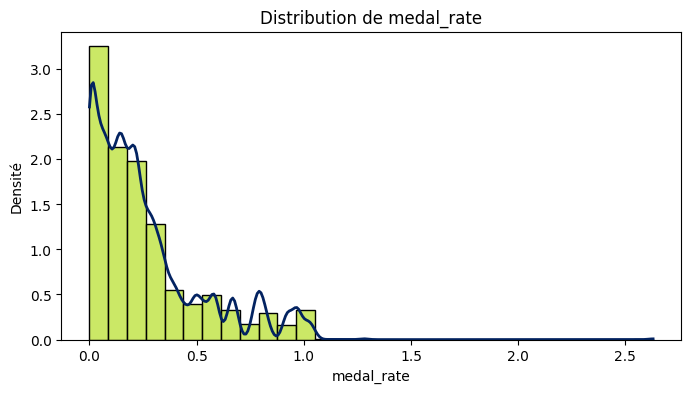

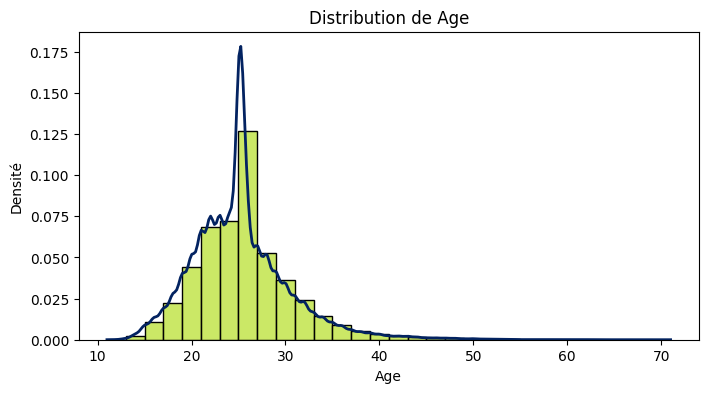

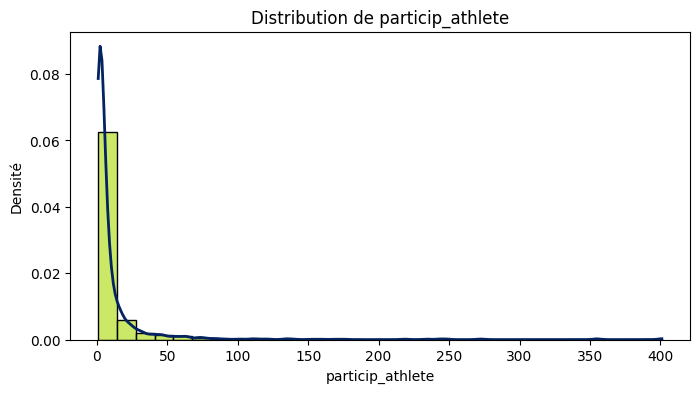

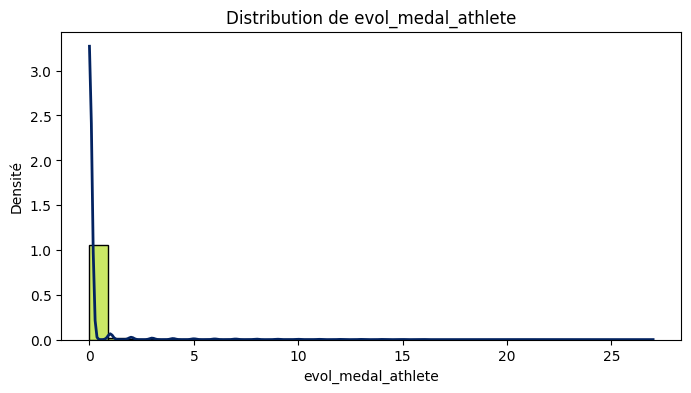

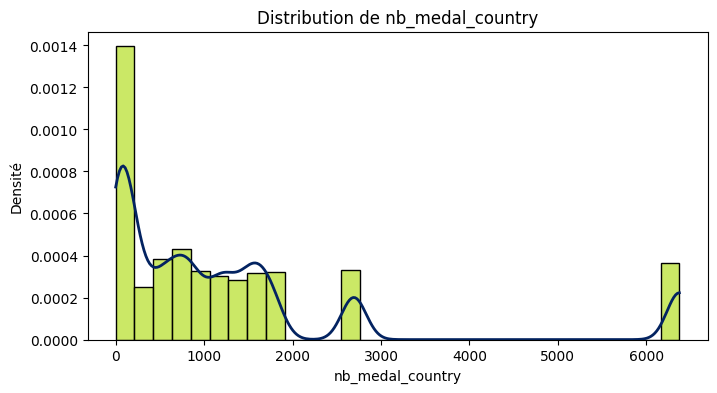

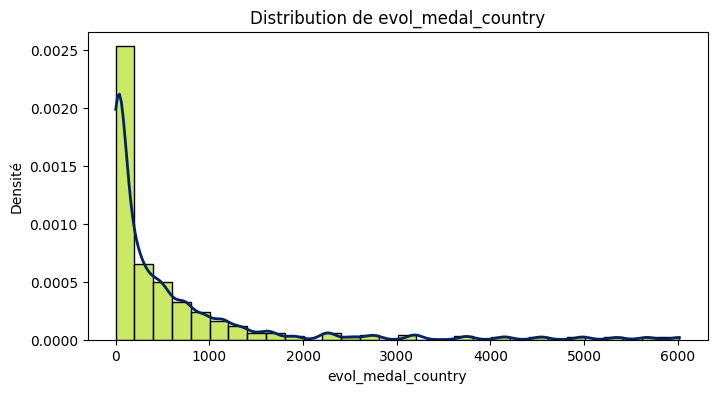

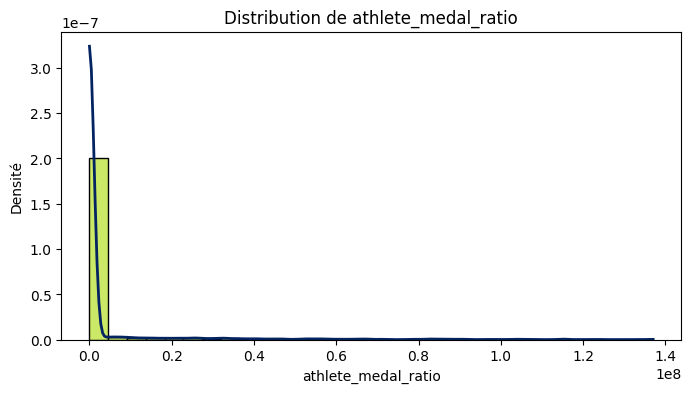

In [100]:
for col in num_cols:
    plt.figure(figsize=(8,4))

    # Histogramme vert
    sns.histplot(
        df_select[col],
        color="#bae133",
        stat="density",
        bins=30
    )

    # KDE bleue (calculée manuellement)
    data = df_select[col].dropna()
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min(), data.max(), 300)
    plt.plot(x_vals, kde(x_vals), color="#032361", linewidth=2)

    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Densité") # Plus la densité est haute, plus les valeurs sont fréquentes dans cette zone.
    plt.show()

OBSERVATION : 
- La majorité des pays ont participé au moins 20 fois à des JO. 
- La majorité des pays sont représentés par 15-20 sports par JO.
- La majorité des pays ont entre 0 & 15 médailles par JO. 
- Sur tout l'historique, la majoirté des pays a été représenté par jusqu'à 500 athlètes. 
- Majorité de la population a environ 23 ans.

---

### **ANALYSE BIVARIÉE**

##### Analyse des variables qualitatives avec Medal

In [101]:
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import matplotlib.pyplot as plt

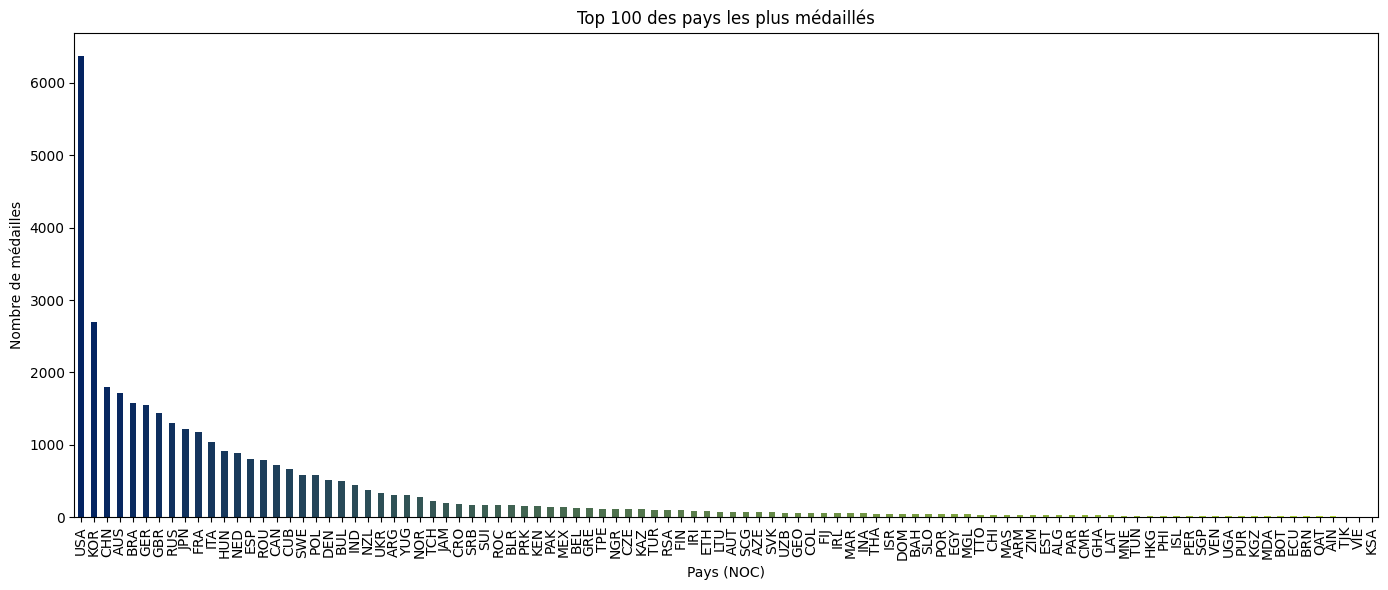

In [102]:
# Top 100 pays les plus médaillés
medals_by_country = (
    df_select.groupby("NOC")["has_medal"]
      .sum()
      .sort_values(ascending=False)
      .head(100)
)

# Dégradé personnalisé entre tes deux couleurs
cmap = LinearSegmentedColormap.from_list(
    "custom",
    ["#032361", "#bae133"]
)

# Générer 100 couleurs pour les 100 pays
colors = [cmap(i) for i in np.linspace(0, 1, 100)]

plt.figure(figsize=(14,6))
medals_by_country.plot(kind="bar", color=colors)

plt.title("Top 100 des pays les plus médaillés")
plt.xlabel("Pays (NOC)")
plt.ylabel("Nombre de médailles")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



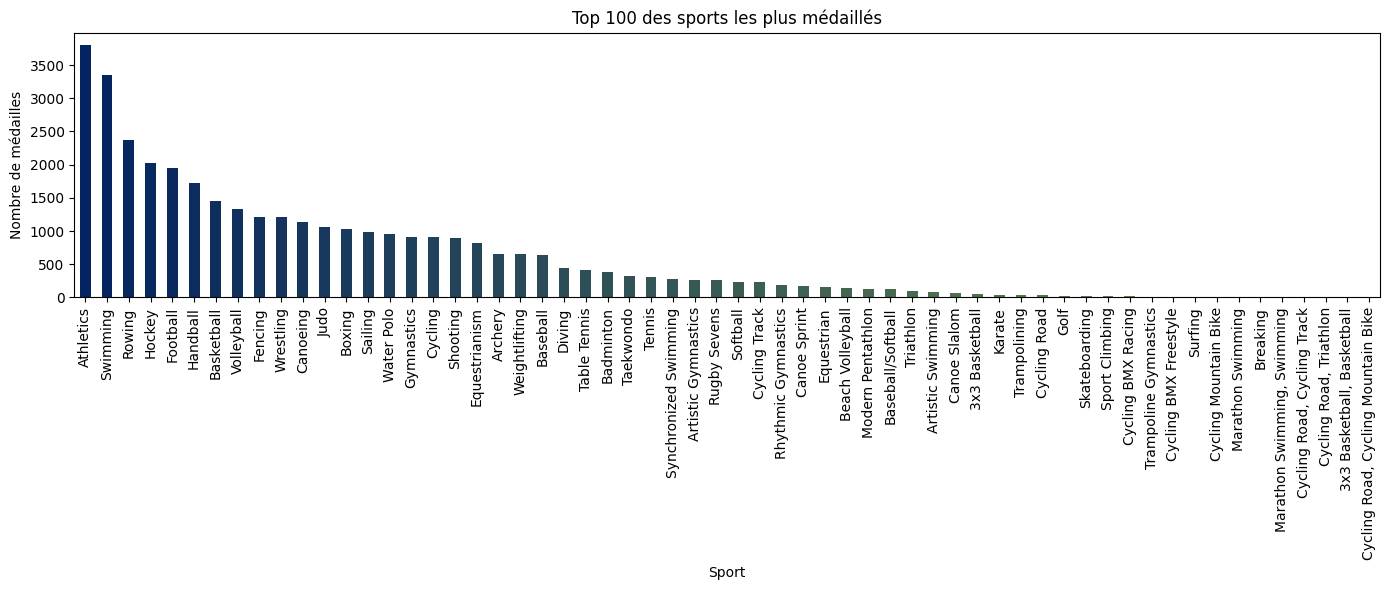

In [103]:
# distribution globale des médailles par PAYS avec limitation des 100 premiers pays 

# Top 100 sports les plus médaillés
medals_by_sport = (
    df_select.groupby("Sport")["has_medal"]
      .sum()
      .sort_values(ascending=False)
      .head(100)
)

# Dégradé personnalisé entre tes deux couleurs
cmap = LinearSegmentedColormap.from_list(
    "custom",
    ["#032361", "#bae133"]
)

# Générer 100 couleurs pour les 100 sports
colors = [cmap(i) for i in np.linspace(0, 1, 100)]

plt.figure(figsize=(14,6))
medals_by_sport.plot(kind="bar", color=colors)

plt.title("Top 100 des sports les plus médaillés")
plt.xlabel("Sport")
plt.ylabel("Nombre de médailles")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


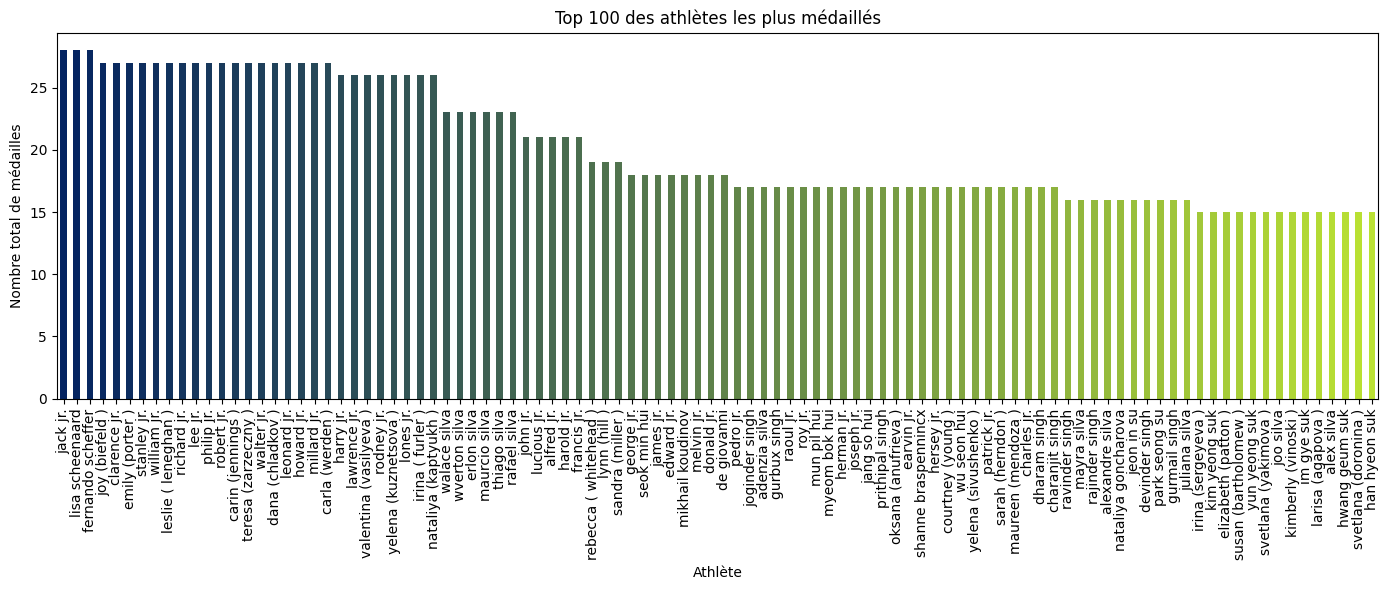

In [104]:
# distribution globale des médailles par ATHLÈTE avec limitation des 100 premiers athlètes 

top_athletes = (
    df_select.groupby("Name")["nb_medal_athlete"]
            .max()   # au cas où plusieurs lignes par athlète
            .sort_values(ascending=False)
            .head(100)
)

# Dégradé personnalisé
cmap = LinearSegmentedColormap.from_list(
    "custom",
    ["#032361", "#bae133"]
)

# Générer 100 couleurs pour les 100 athlètes
colors = [cmap(i) for i in np.linspace(0, 1, 100)]

plt.figure(figsize=(14,6))
top_athletes.plot(kind="bar", color=colors)

plt.title("Top 100 des athlètes les plus médaillés")
plt.xlabel("Athlète")
plt.ylabel("Nombre total de médailles")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<Figure size 1000x400 with 0 Axes>

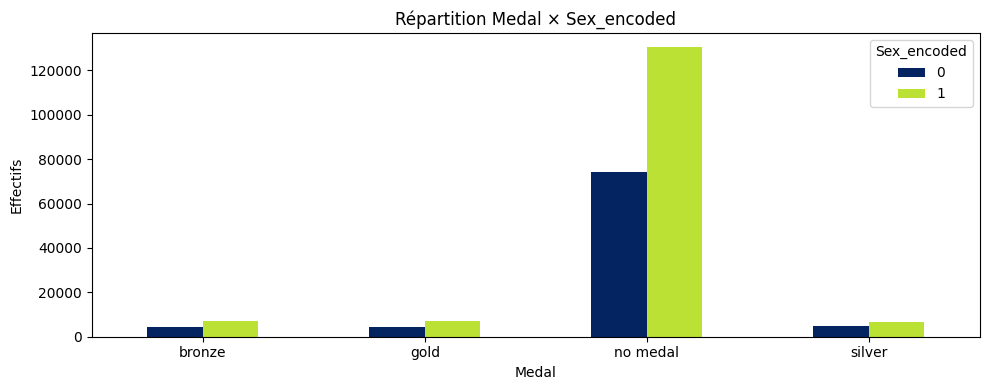

In [105]:
tab = pd.crosstab(df_select.Medal, df_select.Sex_encoded)

plt.figure(figsize=(10,4))

tab.plot(
    kind="bar",
    figsize=(10,4),
    color=["#032361", "#bae133"]   # tes couleurs
)

plt.title("Répartition Medal × Sex_encoded")
plt.xlabel("Medal")
plt.ylabel("Effectifs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [106]:
df_select.columns

Index(['player_id', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport', 'Event',
       'Medal', 'Name', 'Age', 'Sex_encoded', 'Medal_encode', 'Medal_score',
       'has_medal', 'particip_athlete', 'nb_team', 'medal_score_athlete_total',
       'nb_medal_athlete', 'evol_medal_athlete', 'particip_pays',
       'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
       'nb_medal_country', 'evol_medal_country', 'nb_athletes', 'nb_medals',
       'medal_rate', 'athlete_medal_ratio', 'host_NOC', 'is_host_country',
       'first_year_athlete', 'years_since_first', 'recent_athlete'],
      dtype='object')

In [107]:
num_cols = df_select.select_dtypes(include=["int64", "float64"]).columns
num_cols = [c for c in num_cols if c not in ["Medal", "Medal_encode", "has_medal", "Medal_score"]]
num_cols

['player_id',
 'Year',
 'Age',
 'Sex_encoded',
 'particip_athlete',
 'nb_team',
 'medal_score_athlete_total',
 'nb_medal_athlete',
 'evol_medal_athlete',
 'particip_pays',
 'nb_athlete_country',
 'nb_sport_country',
 'medal_score_country_total',
 'nb_medal_country',
 'evol_medal_country',
 'nb_athletes',
 'nb_medals',
 'medal_rate',
 'athlete_medal_ratio',
 'is_host_country',
 'first_year_athlete',
 'years_since_first',
 'recent_athlete']

---

### **CHOIX DES VARIABLES**

##### AUC — Binaire & Multiclasse - (Plus l’AUC est haut, plus la variable prédit bien la médaille)

In [108]:
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

auc_binary = {}
auc_multi = {}

for col in num_cols:
    try:
        # 1) AUC binaire (has_medal)
        model_bin = LogisticRegression()
        model_bin.fit(df_select[[col]], df_select["has_medal"])
        preds_bin = model_bin.predict_proba(df_select[[col]])[:, 1]
        auc_binary[col] = roc_auc_score(df_select["has_medal"], preds_bin)

        # 2) AUC multiclasse (Medal_encode)
        model_multi = LogisticRegression(multi_class="ovr", max_iter=500)
        model_multi.fit(df_select[[col]], df_select["Medal_encode"])
        preds_multi = model_multi.predict_proba(df_select[[col]])
        auc_multi[col] = roc_auc_score(df_select["Medal_encode"], preds_multi,
                                       multi_class="ovr")
    except:
        pass

sorted_auc_binary = dict(sorted(auc_binary.items(), key=lambda x: x[1], reverse=True))
sorted_auc_multi = dict(sorted(auc_multi.items(), key=lambda x: x[1], reverse=True))

sorted_auc_binary, sorted_auc_multi


# Plus l’AUC est élevée, plus la variable est prédictive.

# 1.00 = prédiction parfaite
# 0.50 = aléatoire
# < 0.50 = inutile

({'nb_medal_athlete': 0.996644149737662,
  'medal_score_athlete_total': 0.996606179006188,
  'medal_rate': 0.7150714967458927,
  'nb_medals': 0.6956597110765372,
  'medal_score_country_total': 0.6872635141104042,
  'evol_medal_athlete': 0.6666433056739179,
  'nb_medal_country': 0.6568129103097365,
  'athlete_medal_ratio': 0.6506362103745199,
  'evol_medal_country': 0.6495674074672252,
  'nb_athlete_country': 0.6479733814977138,
  'nb_athletes': 0.6439591302976184,
  'nb_sport_country': 0.6247884392760682,
  'Year': 0.5469875077761326,
  'particip_athlete': 0.5360068535538152,
  'first_year_athlete': 0.534255726018791,
  'years_since_first': 0.534255726018791,
  'Age': 0.53318066214915,
  'recent_athlete': 0.521266529534357,
  'Sex_encoded': 0.5198436248945806,
  'particip_pays': 0.5189306042554654,
  'is_host_country': 0.5116066218542065,
  'player_id': 0.5038641988827682,
  'nb_team': 0.5014044422607778},
 {})

##### Mutual Information — Numérique : Mesure la dépendance non linéaire 

In [109]:
from sklearn.feature_selection import mutual_info_classif

# MI binaire
mi_bin = mutual_info_classif(df_select[num_cols], df_select["has_medal"])
mi_bin_scores = dict(zip(num_cols, mi_bin))
sorted_mi_bin = dict(sorted(mi_bin_scores.items(), key=lambda x: x[1], reverse=True))

# MI multiclasse
mi_multi = mutual_info_classif(df_select[num_cols], df_select["Medal_encode"])
mi_multi_scores = dict(zip(num_cols, mi_multi))
sorted_mi_multi = dict(sorted(mi_multi_scores.items(), key=lambda x: x[1], reverse=True))

sorted_mi_bin, sorted_mi_multi


# MI détecte les relations non linéaires.
# Très fortes dépendances (MI > 0.25)
# Dépendances moyennes (0.05 – 0.10)
# Faible dépendance (0.01 – 0.05)
# Très faible dépendance (< 0.01)

({'nb_medal_athlete': 0.3893239692859526,
  'medal_score_athlete_total': 0.38906821428780625,
  'player_id': 0.1614762827745515,
  'evol_medal_athlete': 0.10323865228269913,
  'athlete_medal_ratio': 0.050263594563370484,
  'medal_rate': 0.04991036330083709,
  'medal_score_country_total': 0.043146300957687345,
  'nb_medals': 0.04192420290823229,
  'nb_team': 0.03888646927958983,
  'Sex_encoded': 0.03644552626359965,
  'nb_athletes': 0.032920310766789695,
  'nb_athlete_country': 0.03176947125523699,
  'evol_medal_country': 0.031560709391164954,
  'nb_medal_country': 0.03042990600356421,
  'particip_pays': 0.018471395503876664,
  'nb_sport_country': 0.016728252522183906,
  'recent_athlete': 0.012031830807130328,
  'particip_athlete': 0.009782853110922751,
  'Year': 0.005876618242217191,
  'years_since_first': 0.005673185264132519,
  'first_year_athlete': 0.004323816641009781,
  'Age': 0.003930134829637444,
  'is_host_country': 0.0004964745038740226},
 {'medal_score_athlete_total': 0.49316

##### Point-bisérial (corrélation binaire) 

In [110]:
# Point-biserial → UNIQUEMENT pour cible binaire

from scipy.stats import pointbiserialr

pb_scores = {}

for col in num_cols:
    try:
        corr, _ = pointbiserialr(df_select[col], df_select["has_medal"])
        pb_scores[col] = abs(corr)
    except:
        pass

sorted_pb = dict(sorted(pb_scores.items(), key=lambda x: x[1], reverse=True))
sorted_pb


# > 0.30 → très forte dépendance
# 0.10 – 0.30 → dépendance moyenne
# 0.02 – 0.10 → dépendance faible
# < 0.02 → quasi inutile

{'nb_medal_athlete': 0.5373968342150722,
 'evol_medal_athlete': 0.36175445751176427,
 'medal_score_athlete_total': 0.28978837263994595,
 'medal_rate': 0.22356075994878383,
 'nb_medals': 0.20380154947677745,
 'nb_medal_country': 0.19206523140720283,
 'nb_athlete_country': 0.18756265101291583,
 'nb_athletes': 0.18248700018730454,
 'evol_medal_country': 0.16784109128968489,
 'nb_sport_country': 0.15490114839831967,
 'medal_score_country_total': 0.12673792951021537,
 'athlete_medal_ratio': 0.09852621260824351,
 'Year': 0.05716602199236098,
 'years_since_first': 0.04211474489912255,
 'first_year_athlete': 0.04211474489912239,
 'recent_athlete': 0.03222712356125832,
 'is_host_country': 0.03157577953542594,
 'Sex_encoded': 0.029314221773569665,
 'Age': 0.02769550000151433,
 'particip_pays': 0.01801558717282662,
 'player_id': 0.016697334242789047,
 'nb_team': 0.011604751074084157,
 'particip_athlete': 0.0057876037782615556}

In [111]:
cat_cols_small = [
    col for col in df_select.select_dtypes(include=["object", "category"]).columns
    if df_select[col].nunique() < 50
]

cat_cols_small # uniquement les colonnes chi²-compatibles.

['Sex', 'City', 'Medal', 'host_NOC']

##### Chi² — Catégoriel : Plus le chi² est élevé, plus la catégorie est informative

In [112]:
# encoder proprement (sans crash)

from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import chi2

enc = OneHotEncoder(drop="first", sparse_output=False)
X_cat = enc.fit_transform(df_select[cat_cols_small])

# Chi² binaire
chi_bin, _ = chi2(X_cat, df_select["has_medal"])
chi_bin_scores = dict(zip(enc.get_feature_names_out(cat_cols_small), chi_bin))
sorted_chi_bin = dict(sorted(chi_bin_scores.items(), key=lambda x: x[1], reverse=True))

# Chi² multiclasse
chi_multi, _ = chi2(X_cat, df_select["Medal_encode"])
chi_multi_scores = dict(zip(enc.get_feature_names_out(cat_cols_small), chi_multi))
sorted_chi_multi = dict(sorted(chi_multi_scores.items(), key=lambda x: x[1], reverse=True))

sorted_chi_bin, sorted_chi_multi


# Plus le chi² est élevé, plus la variable est informative.

({'Medal_gold': 66011.201054048,
  'Medal_silver': 64950.18451446514,
  'Medal_no medal': 33283.96863652362,
  'City_Munich': 280.7706006997368,
  'host_NOC_GER': 280.7706006997368,
  'City_Tokyo': 268.4653752032556,
  'host_NOC_JPN': 268.4653752032556,
  'City_Seoul': 171.65977870251675,
  'host_NOC_KOR': 171.65977870251675,
  'City_Moskva': 81.20610183673794,
  'host_NOC_URS': 81.20610183673794,
  'Sex_M': 75.65914620245681,
  'City_Mexico City': 66.16576226543303,
  'host_NOC_MEX': 66.16576226543303,
  'City_Paris': 63.97149247916232,
  'host_NOC_FRA': 63.97149247916232,
  'City_Barcelona': 45.477028207372975,
  'host_NOC_ESP': 45.477028207372975,
  'City_Beijing': 40.09041464248562,
  'host_NOC_CHN': 40.09041464248562,
  'City_Los Angeles': 29.374331745444014,
  'City_Montreal': 18.44172986675539,
  'host_NOC_CAN': 18.44172986675539,
  'City_London': 15.250097798129712,
  'host_NOC_GBR': 15.250097798129712,
  'host_NOC_GRE': 10.09143913320901,
  'host_NOC_USA': 9.082494121685492,
 

ATTENTION : Les features Medal_gold, Medal_silver, Medal_no medal sont juste l’encodage de la cible → normal qu’elles explosent le score.

**Hors cible :**
Variables host_NOC (pays hôte)

= Elles ont un effet réel mais faible : être pays hôte augmente légèrement les chances de médaille.

**Variables City_**
= Très faible chi² : Quasi aucune information.

La variable Medal est directement la cible, donc son chi² explose.
Être pays hôte augmente la probabilité de médaille, mais l’effet varie selon le pays.

##### MI qualitatif

In [113]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 1) Sélectionner uniquement les colonnes catégorielles à faible cardinalité
cat_cols_small = [
    col for col in df_select.select_dtypes(include=["object", "category"]).columns
    if df_select[col].nunique() < 50
]

# 2) Encoder proprement
enc = OneHotEncoder(drop="first", sparse_output=False)
X_cat = enc.fit_transform(df_select[cat_cols_small])

# 3) Mutual Information
mi_cat = mutual_info_classif(X_cat, df_select["has_medal"])

# 4) Associer MI aux bons noms de features
mi_cat_scores = dict(zip(enc.get_feature_names_out(cat_cols_small), mi_cat))

# 5) Trier
sorted_mi_cat = dict(sorted(mi_cat_scores.items(), key=lambda x: x[1], reverse=True))

sorted_mi_cat


{'Medal_no medal': 0.439281981318545,
 'Medal_gold': 0.09979912881751485,
 'Medal_silver': 0.09891532395900038,
 'Sex_M': 0.037650914272791214,
 'City_Seoul': 0.002684776478694584,
 'City_Tokyo': 0.002626416176011004,
 'host_NOC_FRA': 0.0026023923139510963,
 'City_Paris': 0.002008658650833439,
 'host_NOC_JPN': 0.0016985318585136522,
 'City_Sydney': 0.0015889039707257524,
 'City_Atlanta': 0.0015009381067629946,
 'City_Rio de Janeiro': 0.0014301428835372665,
 'City_Mexico City': 0.0013894576291160199,
 'City_Munich': 0.0013684742930604177,
 'City_Barcelona': 0.0013578580318287514,
 'host_NOC_USA': 0.0013403872711628129,
 'host_NOC_GER': 0.0010414008621129067,
 'City_Los Angeles': 0.0010287269485933503,
 'host_NOC_ESP': 0.0009974496021301071,
 'City_Moskva': 0.0009555998614041439,
 'host_NOC_GBR': 0.0009457745316456823,
 'City_Montreal': 0.0006234546175132305,
 'City_London': 0.0005483040254559146,
 'host_NOC_CHN': 0.000492487672917985,
 'host_NOC_GRE': 0.0003491405652888968,
 'host_NOC_M

---

### **DÉFINITION DU DATAFRAME FINAL**

CIBLE : MEDAL / HAS_MEDAL

**Variables à supprimer pour le modèle (quasi aucune information)**

- particip_athlete
- first_year_athlete
- 'years_since_first'
- 'Year'
- 'recent_athlete' : variable utile seulement pour éviter de proposer des athlètes à la retraite.
- Sex
- City 
- host_NOC
- Team 
- Event 
- Name

In [114]:
df_select.columns

Index(['player_id', 'Sex', 'Team', 'NOC', 'Year', 'City', 'Sport', 'Event',
       'Medal', 'Name', 'Age', 'Sex_encoded', 'Medal_encode', 'Medal_score',
       'has_medal', 'particip_athlete', 'nb_team', 'medal_score_athlete_total',
       'nb_medal_athlete', 'evol_medal_athlete', 'particip_pays',
       'nb_athlete_country', 'nb_sport_country', 'medal_score_country_total',
       'nb_medal_country', 'evol_medal_country', 'nb_athletes', 'nb_medals',
       'medal_rate', 'athlete_medal_ratio', 'host_NOC', 'is_host_country',
       'first_year_athlete', 'years_since_first', 'recent_athlete'],
      dtype='object')

In [131]:
df_model = df_select[[
    'player_id', 'Name', 'NOC', 'Sport', 'Age', 'Sex_encoded',
    'nb_team', 'particip_pays', 'nb_athlete_country',
    'nb_sport_country', 'nb_athletes', 'nb_medals',
    'medal_rate', 'athlete_medal_ratio',
    'is_host_country', 'recent_athlete',
    'has_medal', 'Medal_encode'
]]


In [132]:
df_model.shape

(239159, 18)

In [133]:
df_model.head()

,player_id,Name,NOC,Sport,Age,Sex_encoded,nb_team,particip_pays,nb_athlete_country,nb_sport_country,nb_athletes,nb_medals,medal_rate,athlete_medal_ratio,is_host_country,recent_athlete,has_medal,Medal_encode
0,0,a dijiang,CHN,Basketball,24.0,1,1,11,243,23,394,131,0.332487,1185.004070,0,0,0,0
1,1,a lamusi,CHN,Judo,23.0,1,1,11,365,29,479,166,0.346555,1382.170710,0,1,0,0
2,31,jyri aalto,FIN,Badminton,31.0,1,1,16,70,16,88,5,0.056818,1548.772742,0,0,0,0
3,32,minna aalto,FIN,Sailing,30.0,0,1,16,76,15,105,4,0.038095,2756.177650,0,0,0,0
4,33,minna aalto,FIN,Sailing,34.0,0,1,16,70,16,88,5,0.056818,1548.772742,0,0,0,0


In [134]:
df_model.columns

Index(['player_id', 'Name', 'NOC', 'Sport', 'Age', 'Sex_encoded', 'nb_team',
       'particip_pays', 'nb_athlete_country', 'nb_sport_country',
       'nb_athletes', 'nb_medals', 'medal_rate', 'athlete_medal_ratio',
       'is_host_country', 'recent_athlete', 'has_medal', 'Medal_encode'],
      dtype='object')

---

### **CONSTRUCTION DU MODÈLE DE MACHINE LEARNING**

##### **Import de l'environnement de travail**

In [135]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

##### **Redéfinition des variables**

In [136]:
features = [
    'NOC', 'Sport', 'Age', 'Sex_encoded',
    'nb_team', 'particip_pays', 'nb_athlete_country',
    'nb_sport_country', 'nb_athletes', 'nb_medals',
    'medal_rate', 'athlete_medal_ratio', 'is_host_country'
]

target_binary = 'has_medal'
target_multi  = 'Medal_encode'


##### **Split par sexe et récence**

In [137]:
# Entraînement
df_M_train = df_model[df_model["Sex_encoded"] == 1]
df_F_train = df_model[df_model["Sex_encoded"] == 0]


In [138]:
# Prédiction (athlètes récents)
df_M_pred = df_model[(df_model["Sex_encoded"] == 1) & (df_model["recent_athlete"] == 1)].copy()
df_F_pred = df_model[(df_model["Sex_encoded"] == 0) & (df_model["recent_athlete"] == 1)].copy()

##### **Fabrique de preprocess + modèles**

In [139]:
categorical = ["NOC", "Sport"]
numeric = [col for col in features if col not in categorical]

def make_preprocess():
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
            ("num", "passthrough", numeric)
        ]
    )

def make_model_binary():
    return Pipeline(steps=[
        ("preprocess", make_preprocess()),
        ("clf", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8
        ))
    ])

def make_model_multi():
    return Pipeline(steps=[
        ("preprocess", make_preprocess()),
        ("clf", XGBClassifier(
            objective="multi:softprob",
            num_class=4,
            eval_metric="mlogloss",
            n_estimators=350,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8
        ))
    ])

##### **Optimisation binaire**

In [140]:
from sklearn.model_selection import GridSearchCV

def optimize_binary_model(df_train):
    X = df_train[features]
    y = df_train[target_binary]

    model = make_model_binary()

    pos = y.sum()
    neg = len(y) - pos
    scale = neg / pos

    param_grid = {
        "clf__max_depth": [4, 5, 6],
        "clf__learning_rate": [0.03, 0.05, 0.1],
        "clf__subsample": [0.7, 0.8, 1.0],
        "clf__colsample_bytree": [0.7, 0.8, 1.0],
        "clf__n_estimators": [200, 300, 400],
        "clf__scale_pos_weight": [1, scale, scale * 1.5]
    }

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=3,
        verbose=1,
        n_jobs=-1
    )

    grid.fit(X, y)

    print("Meilleurs paramètres :", grid.best_params_)
    print("Meilleur score AUC :", grid.best_score_)

    return grid.best_estimator_

##### **Optimisation multiclasses**

In [141]:
def optimize_multiclass_model(df_train):
    df_medalists = df_train[df_train["has_medal"] == 1]

    X = df_medalists[features]
    y = df_medalists[target_multi]

    model = make_model_multi()

    param_grid = {
        "clf__max_depth": [4, 5, 6],
        "clf__learning_rate": [0.03, 0.05, 0.1],
        "clf__subsample": [0.7, 0.8, 1.0],
        "clf__colsample_bytree": [0.7, 0.8, 1.0],
        "clf__n_estimators": [250, 350, 450]
    }

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="neg_log_loss",
        cv=3,
        verbose=1,
        n_jobs=-1
    )

    grid.fit(X, y)

    print("Meilleurs paramètres :", grid.best_params_)
    print("Meilleur LogLoss :", grid.best_score_)

    return grid.best_estimator_

##### **Entraînement des 4 modèles (H/F × A/B)**

##### Sex masculin :
**Modèle A — Probabilité de médaille (binaire)**
XGBoostClassifier ou RandomForestClassifier
Sortie : P(has_medal = 1)

**Modèle B — Type de médaille (multiclasse)**
XGBoostClassifier multi:softprob
Sortie : P(gold), P(silver), P(bronze), P(no medal)

In [142]:
############### HOMMES ###############
model_A_M = optimize_binary_model(df_M_train)
model_B_M = optimize_multiclass_model(df_M_train)

Fitting 3 folds for each of 729 candidates, totalling 2187 fits
Meilleurs paramètres : {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__n_estimators': 400, 'clf__scale_pos_weight': 6.082915397234591, 'clf__subsample': 0.8}
Meilleur score AUC : 0.8676441390112001
Fitting 3 folds for each of 243 candidates, totalling 729 fits
Meilleurs paramètres : {'clf__colsample_bytree': 0.7, 'clf__learning_rate': 0.03, 'clf__max_depth': 6, 'clf__n_estimators': 250, 'clf__subsample': 0.7}
Meilleur LogLoss : -1.2269516077840124


##### Sex féminin :
**Modèle A — Probabilité de médaille (binaire)**
XGBoostClassifier ou RandomForestClassifier
Sortie : P(has_medal = 1)

**Modèle B — Type de médaille (multiclasse)**
XGBoostClassifier multi:softprob
Sortie : P(gold), P(silver), P(bronze), P(no medal)

In [143]:
############### FEMMES ###############
model_A_F = optimize_binary_model(df_F_train)
model_B_F = optimize_multiclass_model(df_F_train)

Fitting 3 folds for each of 729 candidates, totalling 2187 fits
Meilleurs paramètres : {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__n_estimators': 400, 'clf__scale_pos_weight': 5.141103438655228, 'clf__subsample': 0.8}
Meilleur score AUC : 0.8497822556084035
Fitting 3 folds for each of 243 candidates, totalling 729 fits
Meilleurs paramètres : {'clf__colsample_bytree': 0.7, 'clf__learning_rate': 0.03, 'clf__max_depth': 6, 'clf__n_estimators': 250, 'clf__subsample': 0.7}
Meilleur LogLoss : -1.3573469680535182


##### **Évaluation du modèle**

In [149]:
# Extraction des médaillés pour l'évaluation multiclasses
df_M_medalists = df_M_train[df_M_train["has_medal"] == 1]
df_F_medalists = df_F_train[df_F_train["has_medal"] == 1]

In [150]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    log_loss
)
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_binary(model, X, y_true, title=""):
    y_proba = model.predict_proba(X)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    print(f"\n===== Évaluation Binaire : {title} =====")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))
    print("AUC      :", roc_auc_score(y_true, y_proba))
    print("LogLoss  :", log_loss(y_true, y_proba))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matrice de confusion — {title}")
    plt.show()


def evaluate_multiclass(model, X, y_true, title=""):
    y_proba = model.predict_proba(X)
    y_pred  = y_proba.argmax(axis=1)

    print(f"\n===== Évaluation Multiclasse : {title} =====")
    print(classification_report(y_true, y_pred))
    print("LogLoss :", log_loss(y_true, y_proba))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
    plt.title(f"Matrice de confusion — {title}")
    plt.show()



===== Évaluation Binaire : Hommes — Modèle A =====
Accuracy : 0.8221276652064005
Precision: 0.4348102158882461
Recall   : 0.8666041715490977
F1-score : 0.579075120973425
AUC      : 0.924560285412316
LogLoss  : 0.374464689257623


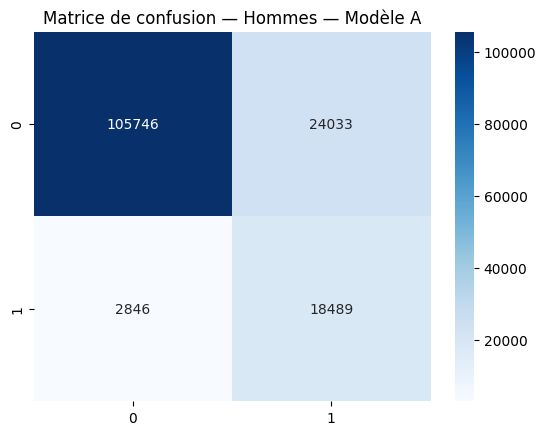


===== Évaluation Multiclasse : Hommes — Modèle B =====
              precision    recall  f1-score   support

           0       0.61      0.62      0.61       629
           1       0.65      0.75      0.70      7063
           2       0.76      0.56      0.65      6552
           3       0.68      0.74      0.71      7091

    accuracy                           0.69     21335
   macro avg       0.68      0.67      0.67     21335
weighted avg       0.69      0.69      0.68     21335

LogLoss : 0.8318636305251708


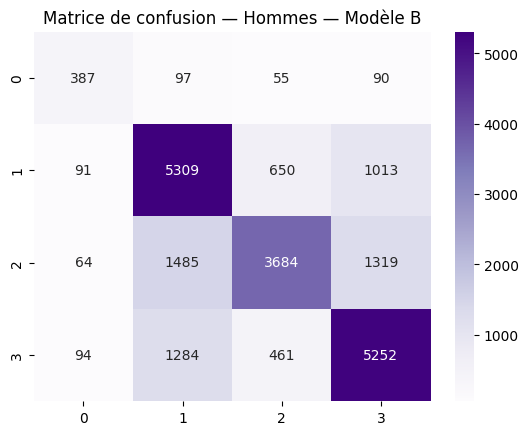

In [151]:
############### HOMMES — Binaire ###############

evaluate_binary(model_A_M, df_M_train[features], df_M_train[target_binary],
                title="Hommes — Modèle A")

evaluate_multiclass(model_B_M, df_M_medalists[features], df_M_medalists[target_multi],
                    title="Hommes — Modèle B")


===== Évaluation Binaire : Femmes — Modèle A =====
Accuracy : 0.8445794764041116
Precision: 0.513424612474816
Recall   : 0.8709632419613588
F1-score : 0.646024108851984
AUC      : 0.9386694732751555
LogLoss  : 0.34933969974716106


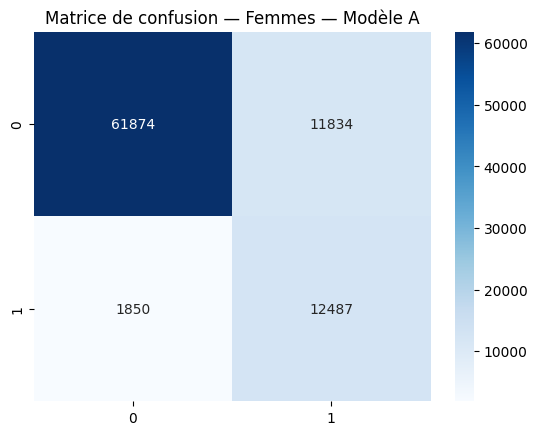


===== Évaluation Multiclasse : Femmes — Modèle B =====
              precision    recall  f1-score   support

           0       0.64      0.52      0.58       491
           1       0.73      0.76      0.74      4531
           2       0.80      0.71      0.75      4834
           3       0.72      0.79      0.75      4481

    accuracy                           0.74     14337
   macro avg       0.72      0.69      0.71     14337
weighted avg       0.75      0.74      0.74     14337

LogLoss : 0.7709259325058161


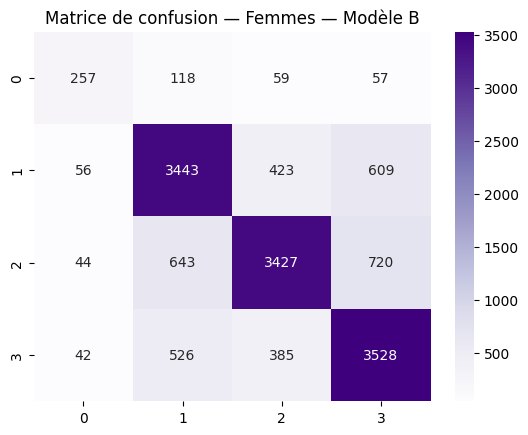

In [152]:
############### FEMMES — Binaire ###############

evaluate_binary(model_A_F, df_F_train[features], df_F_train[target_binary],
                title="Femmes — Modèle A")

evaluate_multiclass(model_B_F, df_F_medalists[features], df_F_medalists[target_multi],
                    title="Femmes — Modèle B")


##### **Seuil optimal**

In [153]:
from sklearn.metrics import roc_curve

def find_optimal_threshold(model, X, y):
    y_proba = model.predict_proba(X)[:, 1]
    fpr, tpr, thresholds = roc_curve(y, y_proba)
    idx = (tpr - fpr).argmax()
    return thresholds[idx]

threshold_M = find_optimal_threshold(model_A_M, df_M_train[features], df_M_train[target_binary])
threshold_F = find_optimal_threshold(model_A_F, df_F_train[features], df_F_train[target_binary])

print("Seuil optimal Hommes :", threshold_M)
print("Seuil optimal Femmes :", threshold_F)


Seuil optimal Hommes : 0.5058620572090149
Seuil optimal Femmes : 0.5098457932472229


##### **Prédictions JO 2028**

In [154]:
############### HOMMES ###############
df_M_pred["P_medal"] = model_A_M.predict_proba(df_M_pred[features])[:, 1]
df_M_pred["has_medal_pred"] = (df_M_pred["P_medal"] >= threshold_M).astype(int)

df_M_pred[["P_no", "P_bronze", "P_silver", "P_gold"]] = \
    model_B_M.predict_proba(df_M_pred[features])

############### FEMMES ###############
df_F_pred["P_medal"] = model_A_F.predict_proba(df_F_pred[features])[:, 1]
df_F_pred["has_medal_pred"] = (df_F_pred["P_medal"] >= threshold_F).astype(int)

df_F_pred[["P_no", "P_bronze", "P_silver", "P_gold"]] = \
    model_B_F.predict_proba(df_F_pred[features])


##### **Scores finaux (côte athlète)**

In [155]:
for df in [df_M_pred, df_F_pred]:
    df["Score_gold"]   = df["P_medal"] * df["P_gold"]
    df["Score_silver"] = df["P_medal"] * df["P_silver"]
    df["Score_bronze"] = df["P_medal"] * df["P_bronze"]

    df["Cote_athlete"] = (
        df["Score_gold"] * 3 +
        df["Score_silver"] * 2 +
        df["Score_bronze"] * 1
    )

##### **Fusion**

In [156]:
df_pred_all = pd.concat([df_M_pred, df_F_pred], axis=0)

##### **Classements**

In [157]:
# Athlètes par sport

ranking_athletes_by_sport = (
    df_pred_all
    .sort_values(["Sport", "Cote_athlete"], ascending=[True, False])
    .groupby("Sport", group_keys=False)
    .apply(lambda x: x[["player_id","Name", "NOC", "Cote_athlete", "P_medal", "P_gold"]]
           .reset_index(drop=True))
)

In [158]:
# Pays par sport

ranking_countries_by_sport = (
    df_pred_all
    .groupby(["Sport", "NOC"])
    .agg(
        Cote_country=("Cote_athlete", "sum"),
        Medal_prob=("P_medal", "mean"),
        Gold_prob=("P_gold", "mean")
    )
    .sort_values(["Sport", "Cote_country"], ascending=[True, False])
)

In [159]:
# Top 3 sports

top3_sports = (
    df_pred_all.groupby("Sport")["Cote_athlete"]
    .mean()
    .sort_values(ascending=False)
    .head(3)
)

In [160]:
# Top 3 athlètes

top3_athletes = (
    df_pred_all
    .sort_values("Cote_athlete", ascending=False)
    [["player_id","Name", "Sport", "NOC", "Cote_athlete", "P_medal", "P_gold"]]
    .head(3)
)

---

### **MISE EN PLACE DES VARIABLES DE DASHBOARD**

In [161]:
df_select.to_csv("historique_jo.csv", index=False)
df_pred_all.to_csv("predictions_2028.csv", index=False)

In [199]:
df_pred_all.columns

Index(['player_id', 'Name', 'NOC', 'Sport', 'Age', 'Sex_encoded', 'nb_team',
       'particip_pays', 'nb_athlete_country', 'nb_sport_country',
       'nb_athletes', 'nb_medals', 'medal_rate', 'athlete_medal_ratio',
       'is_host_country', 'recent_athlete', 'has_medal', 'Medal_encode',
       'P_medal', 'has_medal_pred', 'P_no', 'P_bronze', 'P_silver', 'P_gold',
       'Score_gold', 'Score_silver', 'Score_bronze', 'Cote_athlete'],
      dtype='object')

In [162]:
df_select["NOC"].unique()

array(['CHN', 'FIN', 'NOR', 'ROU', 'NED', 'FRA', 'MAR', 'EST', 'ESP',
       'EGY', 'BUL', 'ITA', 'CHA', 'AZE', 'SUD', 'RUS', 'ARG', 'CUB',
       'BLR', 'GRE', 'CMR', 'TUR', 'MEX', 'CHI', 'USA', 'NCA', 'HUN',
       'NGR', 'ALG', 'KUW', 'BRN', 'PAK', 'IRQ', 'LIB', 'QAT', 'MAS',
       'IRI', 'CAN', 'IRL', 'AUS', 'RSA', 'ERI', 'TAN', 'JOR', 'TUN',
       'LBA', 'BEL', 'DJI', 'PLE', 'COM', 'KAZ', 'BRU', 'KSA', 'SYR',
       'MDV', 'ETH', 'UAE', 'YAR', 'INA', 'PHI', 'SGP', 'UZB', 'KGZ',
       'TJK', 'JPN', 'CGO', 'BRA', 'GER', 'SWE', 'SRI', 'ARM', 'CIV',
       'KEN', 'BEN', 'GHA', 'SOM', 'NIG', 'MLI', 'GBR', 'SUI', 'IND',
       'POL', 'CRC', 'PAN', 'GEO', 'SLO', 'GUY', 'POR', 'PAR', 'ANG',
       'VEN', 'COL', 'BAN', 'PER', 'URU', 'ESA', 'PUR', 'UGA', 'NZL',
       'HON', 'ECU', 'TKM', 'MRI', 'SEY', 'TCH', 'MTN', 'SKN', 'TTO',
       'DOM', 'VIN', 'JAM', 'LBR', 'SUR', 'NEP', 'MGL', 'PLW', 'LTU',
       'MON', 'TOG', 'NAM', 'AHO', 'UKR', 'ISL', 'ASA', 'AUT', 'SAM',
       'RWA', 'CRO',

---

### **DÉVELOPPEMENT DU DASHBOARD**

In [203]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px

# ---------------------------------------------------------
# CONFIGURATION STREAMLIT
# ---------------------------------------------------------
st.set_page_config(page_title="Analyse & Prédiction JO", layout="wide")

# ---------------------------------------------------------
# CHARGEMENT DES DONNÉES
# ---------------------------------------------------------
df_hist = pd.read_csv("historique_jo.csv")
df_pred_all = pd.read_csv("predictions_2028.csv")

df_hist["Year"] = df_hist["Year"].astype(int)

# ---------------------------------------------------------
# DICTIONNAIRE NOC → PAYS
# ---------------------------------------------------------

noc_to_country = {
    "CHN": "Chine", "FIN": "Finlande", "NOR": "Norvège", "ROU": "Roumanie",
    "NED": "Pays-Bas", "FRA": "France", "MAR": "Maroc", "EST": "Estonie",
    "ESP": "Espagne", "EGY": "Égypte", "BUL": "Bulgarie", "ITA": "Italie",
    "CHA": "Tchad", "AZE": "Azerbaïdjan", "SUD": "Soudan", "RUS": "Russie",
    "ARG": "Argentine", "CUB": "Cuba", "BLR": "Biélorussie", "GRE": "Grèce",
    "CMR": "Cameroun", "TUR": "Turquie", "MEX": "Mexique", "CHI": "Chili",
    "USA": "États-Unis", "NCA": "Nicaragua", "HUN": "Hongrie", "NGR": "Nigeria",
    "ALG": "Algérie", "KUW": "Koweït", "BRN": "Bahreïn", "PAK": "Pakistan",
    "IRQ": "Irak", "LIB": "Liban", "QAT": "Qatar", "MAS": "Malaisie",
    "IRI": "Iran", "CAN": "Canada", "IRL": "Irlande", "AUS": "Australie",
    "RSA": "Afrique du Sud", "ERI": "Érythrée", "TAN": "Tanzanie",
    "JOR": "Jordanie", "TUN": "Tunisie", "LBA": "Libye", "BEL": "Belgique",
    "DJI": "Djibouti", "PLE": "Palestine", "COM": "Comores", "KAZ": "Kazakhstan",
    "BRU": "Brunei", "KSA": "Arabie Saoudite", "SYR": "Syrie", "MDV": "Maldives",
    "ETH": "Éthiopie", "UAE": "Émirats arabes unis", "YAR": "Yémen du Nord",
    "INA": "Indonésie", "PHI": "Philippines", "SGP": "Singapour",
    "UZB": "Ouzbékistan", "KGZ": "Kirghizistan", "TJK": "Tadjikistan",
    "JPN": "Japon", "CGO": "Congo", "BRA": "Brésil", "GER": "Allemagne",
    "SWE": "Suède", "SRI": "Sri Lanka", "ARM": "Arménie", "CIV": "Côte d’Ivoire",
    "KEN": "Kenya", "BEN": "Bénin", "GHA": "Ghana", "SOM": "Somalie",
    "NIG": "Niger", "MLI": "Mali", "GBR": "Royaume-Uni", "SUI": "Suisse",
    "IND": "Inde", "POL": "Pologne", "CRC": "Costa Rica", "PAN": "Panama",
    "GEO": "Géorgie", "SLO": "Slovénie", "GUY": "Guyana", "POR": "Portugal",
    "PAR": "Paraguay", "ANG": "Angola", "VEN": "Venezuela", "COL": "Colombie",
    "BAN": "Bangladesh", "PER": "Pérou", "URU": "Uruguay", "ESA": "Salvador",
    "PUR": "Porto Rico", "UGA": "Ouganda", "NZL": "Nouvelle-Zélande",
    "HON": "Honduras", "ECU": "Équateur", "TKM": "Turkménistan",
    "MRI": "Maurice", "SEY": "Seychelles", "TCH": "Tchécoslovaquie",
    "MTN": "Mauritanie", "SKN": "Saint-Kitts-et-Nevis", "TTO": "Trinité-et-Tobago",
    "DOM": "République dominicaine", "VIN": "Saint-Vincent-et-les-Grenadines",
    "JAM": "Jamaïque", "LBR": "Libéria", "SUR": "Suriname", "NEP": "Népal",
    "MGL": "Mongolie", "PLW": "Palaos", "LTU": "Lituanie", "MON": "Monaco",
    "TOG": "Togo", "NAM": "Namibie", "AHO": "Antilles néerlandaises",
    "UKR": "Ukraine", "ISL": "Islande", "ASA": "Samoa américaines",
    "AUT": "Autriche", "SAM": "Samoa", "RWA": "Rwanda", "CRO": "Croatie",
    "DMA": "Dominique", "HAI": "Haïti", "DEN": "Danemark", "MLT": "Malte",
    "LUX": "Luxembourg", "CYP": "Chypre", "GUI": "Guinée", "BIZ": "Belize",
    "YMD": "Yémen du Sud", "BER": "Bermudes", "SCG": "Serbie-et-Monténégro",
    "SLE": "Sierra Leone", "PNG": "Papouasie-Nouvelle-Guinée", "AFG": "Afghanistan",
    "YEM": "Yémen", "IOA": "Athlètes olympiques indépendants", "OMA": "Oman",
    "FIJ": "Fidji", "VAN": "Vanuatu", "MDA": "Moldavie", "BAH": "Bahamas",
    "GUA": "Guatemala", "YUG": "Yougoslavie", "LAT": "Lettonie", "ISR": "Israël",
    "SRB": "Serbie", "IVB": "Îles Vierges britanniques", "MOZ": "Mozambique",
    "ISV": "Îles Vierges américaines", "CAF": "République centrafricaine",
    "MAD": "Madagascar", "BIH": "Bosnie-Herzégovine", "GUM": "Guam",
    "CAY": "Îles Caïmans", "SVK": "Slovaquie", "BAR": "Barbade",
    "GBS": "Guinée-Bissau", "THA": "Thaïlande", "TLS": "Timor oriental",
    "COD": "République démocratique du Congo", "GAB": "Gabon", "SMR": "Saint-Marin",
    "LAO": "Laos", "BOT": "Botswana", "ROT": "Équipe olympique des réfugiés",
    "KOR": "Corée du Sud", "CAM": "Cambodge", "PRK": "Corée du Nord",
    "SOL": "Îles Salomon", "SEN": "Sénégal", "CPV": "Cap-Vert", "CZE": "Tchéquie",
    "GEQ": "Guinée équatoriale", "BOL": "Bolivie", "ANT": "Antilles",
    "AND": "Andorre", "ZIM": "Zimbabwe", "GRN": "Grenade", "HKG": "Hong Kong",
    "LCA": "Sainte-Lucie", "FSM": "États fédérés de Micronésie",
    "MYA": "Myanmar", "MAW": "Malawi", "ZAM": "Zambie", "TPE": "Taïwan",
    "STP": "Sao Tomé-et-Principe", "MKD": "Macédoine du Nord", "LIE": "Liechtenstein",
    "MNE": "Monténégro", "GAM": "Gambie", "COK": "Îles Cook", "ALB": "Albanie",
    "SWZ": "Eswatini", "BUR": "Burkina Faso", "BDI": "Burundi", "ARU": "Aruba",
    "NRU": "Nauru", "VNM": "Vietnam", "VIE": "Vietnam", "BHU": "Bhoutan",
    "MHL": "Îles Marshall", "KIR": "Kiribati", "TUV": "Tuvalu", "TGA": "Tonga",
    "KOS": "Kosovo", "SSD": "Soudan du Sud", "LES": "Lesotho",
    "ROC": "Comité Olympique Russe", "EOR": "Équipe olympique des réfugiés",
    "LBN": "Liban", "AIN": "Athlètes indépendants"
}



df_hist["Country"] = df_hist["NOC"].map(noc_to_country).fillna(df_hist["NOC"])
df_pred_all["Country"] = df_pred_all["NOC"].map(noc_to_country).fillna(df_pred_all["NOC"])

# ---------------------------------------------------------
# MAPPINGS SEXE
# ---------------------------------------------------------
df_hist["Sex"] = df_hist["Sex_encoded"].map({1: "Homme", 0: "Femme"})
df_pred_all["Sex"] = df_pred_all["Sex_encoded"].map({1: "Homme", 0: "Femme"})

# ---------------------------------------------------------
# PLAYER ID
# ---------------------------------------------------------
if "player_id" not in df_hist.columns:
    df_hist["player_id"] = df_hist["Name"] + "_" + df_hist["NOC"] + "_" + df_hist["Sex"]

if "player_id" not in df_pred_all.columns:
    df_pred_all["player_id"] = df_pred_all["Name"] + "_" + df_pred_all["NOC"] + "_" + df_pred_all["Sex"]

# ---------------------------------------------------------
# STYLE PLOTLY
# ---------------------------------------------------------
def style_fig(fig):
    fig.update_layout(
        template="simple_white",
        paper_bgcolor="white",
        plot_bgcolor="white",
        title_font=dict(size=20, color="#032361", family="Codec Pro"),
        xaxis=dict(showline=True, linecolor="#032361", tickfont=dict(color="#032361"), gridcolor="#e6e6e6"),
        yaxis=dict(showline=True, linecolor="#032361", tickfont=dict(color="#032361"), gridcolor="#e6e6e6"),
        legend=dict(font=dict(color="#032361"), bgcolor="rgba(0,0,0,0)"),
        margin=dict(l=20, r=20, t=40, b=20)
    )
    fig.update_traces(
        marker_color="#bae133",
        marker_line_color="#032361",
        marker_line_width=1.2
    )
    return fig

# ---------------------------------------------------------
# CSS GLOBAL
# ---------------------------------------------------------
st.markdown(
    """
    <style>

        .stApp { background-color: #ffffff !important; }

        h1, h2, h3, h4, p, label, span, div, .section-title, .subtitle {
            color: #032361 !important;
            font-family: 'Codec Pro', 'Arial', sans-serif;
        }

        h1 {
            font-size: 42px !important;
            text-transform: uppercase;
            font-weight: 900;
            text-align: center !important;
        }

        .subtitle {
            font-size: 18px;
            font-weight: 300;
            margin-top: -10px;
            margin-bottom: 20px;
            text-align: center;
        }

        /* Onglets */
        .stTabs [data-baseweb="tab"] button p {
            color: #032361 !important;
            font-size: 18px !important;
            font-weight: 700 !important;
            text-transform: uppercase;
        }

        /* Filtres déroulants bleus */
        div[data-baseweb="select"] > div {
            background-color: #00256d !important;
            color: white !important;
        }

        /* AJOUT : texte des menus déroulants en blanc */
        div[data-baseweb="select"] * {
            color: white !important;
        }
        div[data-baseweb="select"] span {
            color: white !important;
        }
        div[data-baseweb="select"] svg {
            fill: white !important;
        }

        /* KPI bleu foncé */
        .kpi-card {
            background-color: #032361 !important;
            border-radius: 10px !important;
            padding: 18px 20px !important;
            margin-bottom: 16px !important;
            color: white !important;
        }

        .kpi-card .stMetric label,
        .kpi-card .stMetric div,
        .kpi-card .stMetric span {
            color: white !important;
        }

        /* Graph cards full white */
        .graph-card {
            background-color: #ffffff !important;
            border: none !important;
            padding: 0 !important;
            margin-bottom: 16px !important;
        }

    </style>
    """,
    unsafe_allow_html=True
)



# ---------------------------------------------------------
# HEADER PREMIUM
# ---------------------------------------------------------
st.markdown("<h1>Analyse et Prédictions des Jeux Olympiques</h1>", unsafe_allow_html=True)

st.markdown(
    '<div class="subtitle-wrap"><p class="subtitle">'
    "L'application qui analyse les performances sportives<br>passées, pour prédire les futures"
    '</p></div>',
    unsafe_allow_html=True
)

# ---------------------------------------------------------
# ONGLET STRUCTURE
# ---------------------------------------------------------
tab1, tab2 = st.tabs(["Analyse de perf", "Prédictions"])


# =========================================================
# ONGLET ANALYSE
# =========================================================
with tab1:

    # ---------------- FILTRES ----------------
    st.markdown("<h3 class='section-title'>Filtres</h3>", unsafe_allow_html=True)

    c1, c2, c3, c4 = st.columns(4)

    selected_year = c1.selectbox("Éditions", sorted(df_hist["Year"].unique()), key="year_analyse")
    selected_sport = c2.selectbox("Sport", ["Tous"] + sorted(df_hist["Sport"].unique()), key="sport_analyse")
    selected_noc = c3.selectbox("Pays", ["Tous"] + sorted(df_hist["Country"].unique()), key="pays_analyse")
    selected_sex = c4.selectbox("Genre", ["Tous", "Homme", "Femme"], key="genre_analyse")

    # ---------------- APPLICATION DES FILTRES ----------------
    df_r = df_hist.copy()
    df_r = df_r[df_r["Year"] == selected_year]

    if selected_sport != "Tous":
        df_r = df_r[df_r["Sport"] == selected_sport]

    if selected_noc != "Tous":
        df_r = df_r[df_r["Country"] == selected_noc]

    if selected_sex != "Tous":
        df_r = df_r[df_r["Sex"] == selected_sex]

    # ---------------- KPI ----------------
    
    st.markdown("<h3 class='section-title'>Indicateurs clés</h3>", unsafe_allow_html=True)

    k1, k2, k3, k4 = st.columns(4)

    k1.metric("Total médailles", int(df_r["has_medal"].sum()))
    k2.metric("Pays représentés", df_r["Country"].nunique())
    k3.metric("Taux de médailles", f"{df_r['has_medal'].mean():.2%}")
    k4.metric("Total sports", df_r["Sport"].nunique())


    # ---------------- MÉDAILLES PAR PAYS ----------------
    st.markdown("<h3 class='section-title'>Médailles par pays</h3>", unsafe_allow_html=True)

    medals_country = (
        df_r.groupby("Country")["has_medal"]
        .sum()
        .sort_values(ascending=False)
        .reset_index(name="nb_medals")
    )

    fig_country = px.bar(
        medals_country.head(10),
        x="Country",
        y="nb_medals",
        title="Top 10 des pays (médailles)",
        labels={"Country": "Pays", "nb_medals": "Nombre de médailles"}
    )

    st.plotly_chart(style_fig(fig_country), use_container_width=True)

# ---------------- MÉDAILLES PAR SPORT ----------------
    st.markdown("<h3 class='section-title'>Médailles par sport</h3>", unsafe_allow_html=True)

    medals_sport = (
        df_r.groupby("Sport")["has_medal"]
        .sum()
        .sort_values(ascending=False)
        .reset_index(name="nb_medals")
    )

    fig_sport = px.bar(
        medals_sport.head(10),
        x="Sport",
        y="nb_medals",
        title="Top 10 des sports (médailles)",
        labels={"Sport": "Sport", "nb_medals": "Nombre de médailles"}
    )

    st.plotly_chart(style_fig(fig_sport), use_container_width=True)

# =========================================================
# ONGLET PRÉDICTION
# =========================================================
with tab2:

    st.markdown("<h2 class='section-title'>Prédictions JO 2028</h2>", unsafe_allow_html=True)

    dfp = df_pred_all.copy()

    # ---------------- FILTRES ----------------
    col1, col2, col3, col4, col5 = st.columns(5)

    sexe_label_pred = col1.selectbox("Genre", ["Homme", "Femme"], key="genre_pred")

    sports_pred = sorted(dfp["Sport"].dropna().unique())
    selected_sport_pred = col2.selectbox("Sport", ["Tous"] + sports_pred, key="sport_pred")

    nocs_pred = sorted(dfp["Country"].dropna().unique())
    selected_noc_pred = col3.selectbox("Pays", ["Tous"] + nocs_pred, key="pays_pred")

    top_n = col4.slider("Top N", 5, 100, 20, 5, key="top_pred")

    # 🔥 AJOUT : seuil médaille
    seuil = col5.slider("Seuil médaille", 0.0, 1.0, 0.5, 0.01, key="seuil_pred")

    # ---------------- APPLICATION DES FILTRES ----------------
    dfp = dfp[dfp["Sex"] == sexe_label_pred]

    if selected_sport_pred != "Tous":
        dfp = dfp[dfp["Sport"] == selected_sport_pred]

    if selected_noc_pred != "Tous":
        dfp = dfp[dfp["Country"] == selected_noc_pred]

    # ---------------- DÉDOUBLONNER PAR ATHLÈTE ----------------
    dfp_unique = (
        dfp.sort_values("P_medal", ascending=False)
           .drop_duplicates("player_id")
           .reset_index(drop=True)
    )

    # ---------------- KPIs ----------------
    st.markdown("<h3 class='section-title'>Indicateurs principaux</h3>", unsafe_allow_html=True)
    st.markdown("<div class='kpi-card'>", unsafe_allow_html=True)

    colk1, colk2, colk3 = st.columns(3)
    colk1.metric("Nombre d'athlètes", dfp_unique["player_id"].nunique())
    colk2.metric("Nombre de pays", dfp_unique["Country"].nunique())
    colk3.metric("Probabilité moyenne médaille", f"{dfp_unique['P_medal'].mean():.2%}")

    st.markdown("</div>", unsafe_allow_html=True)

    # ---------------- TOP PAYS ----------------
    st.markdown("<h3 class='section-title'>Top pays</h3>", unsafe_allow_html=True)

    df_country = (
        dfp_unique.groupby("Country")
        .agg(
            Prob_medal=("P_medal", "mean"),
            Prob_gold=("P_gold", "mean"),
            Athletes=("player_id", "nunique")
        )
        .reset_index()
        .sort_values("Prob_medal", ascending=False)
    )

    st.dataframe(df_country.head(top_n), use_container_width=True)

    # ---------------- TOP ATHLÈTES ----------------
    st.markdown("<h3 class='section-title'>Top athlètes</h3>", unsafe_allow_html=True)

    df_ath = (
        dfp_unique.sort_values("P_medal", ascending=False)[
            ["player_id", "Name", "Country", "Sport", "P_medal", "P_gold"]
        ]
    )

    df_ath = df_ath.rename(columns={
        "player_id": "ID Athlète",
        "Name": "Athlète",
        "Country": "Pays",
        "Sport": "Sport",
        "P_medal": "Probabilité médaille",
        "P_gold": "Probabilité or"
    })

    st.dataframe(df_ath.head(top_n), use_container_width=True)

    # =========================================================
    # COMPARAISON JO 2024 vs JO 2028 (recent + distinct player_id)
    # =========================================================

    st.markdown("<h2 class='section-title'>Comparaison JO 2024 vs JO 2028</h2>", unsafe_allow_html=True)

    # --- Médailles réelles 2024 ---
    df_2024 = df_hist[df_hist["Year"] == 2024]

    medals_2024 = (
        df_2024.groupby("Country")["has_medal"]
        .sum()
        .reset_index(name="Medals_2024")
    )

    # --- Médailles prédites 2028 ---
    dfp_global = df_pred_all[df_pred_all["recent_athlete"] == 1].copy()

    dfp_global = (
        dfp_global.sort_values("P_medal", ascending=False)
                .drop_duplicates("player_id")
                .reset_index(drop=True)
    )

    dfp_global["has_medal_pred"] = (dfp_global["P_medal"] >= seuil).astype(int)

    pred_2028 = (
        dfp_global.groupby("Country")["has_medal_pred"]
        .sum()
        .reset_index(name="Pred_2028")
    )

    df_compare = medals_2024.merge(pred_2028, on="Country", how="outer").fillna(0)
    df_compare["Évolution"] = df_compare["Pred_2028"] - df_compare["Medals_2024"]

    st.dataframe(
        df_compare.sort_values("Évolution", ascending=False),
        use_container_width=True
    )



Overwriting app.py


In [ ]:
# DANS LE TERMINAL : 
    # cd "chemin"
    # !streamlit run app.py

---